# Transparent Surface Cues Lab

Goal: run physically grounded experiments for transparent/glass multilayer depth cues using local-only shards.

This notebook focuses on insight discovery, not model training.

Dataset semantics used in this notebook:

- Real benchmark supervision is sparse relative-depth tuples with per-point layer IDs (no dense metric depth map in real split).
- Synthetic supervision provides dense multi-layer depth maps (for example depth_1.png ... depth_k.png).

Experiments included:

- Experiment A: FFT high-pass frequency segregation
- Experiment A2: FRFT order sweep
- Experiment B: HSV specular split
- Experiment D: distortion and line-bending cue
- Experiment E: blur/focus residual cue
- Experiment F: multiscale detail persistence (wavelet-like without extra deps)

Primary objective: identify cues that can be translated into model inputs, losses, or preprocessing pipelines for multilayer depth estimation.

## 1. Import Dependencies

Imports are grouped and followed by a quick reproducibility/version check.

In [40]:
import gc
import json
import random
import re
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset

import sys

try:
    import psutil  # optional, used for lightweight RSS tracking
except Exception:
    psutil = None

CWD = Path.cwd().resolve()
ROOT = CWD
for cand in [CWD, *CWD.parents]:
    if (cand / "src" / "lbp_project").exists():
        ROOT = cand
        break

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from lbp_project.utils.metrics import evaluate_tuple_sample, summarize_tuple_counts

plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["image.cmap"] = "gray"

print("ROOT:", ROOT)
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("opencv:", cv2.__version__)
print("psutil:", getattr(psutil, "__version__", "not-installed"))

ROOT: /home/yash_gupta/lbp/lbp
numpy: 2.2.6
torch: 2.10.0+cu128
opencv: 4.13.0
psutil: 7.2.2


## 2. Set Up Configuration

Central configuration keeps paths, sample sizes, and runtime flags in one place.

In [54]:
@dataclass
class ExperimentConfig:
    cache_root: Path = Path("/home/yash_gupta/.cache/huggingface/datasets")
    syn_pattern: str = "princeton-vl___layered_depth-syn/default/*/*/layered_depth-syn-train-*.arrow"
    real_pattern: str = "princeton-vl___layered_depth/default/*/*/layered_depth-validation-*.arrow"
    output_dir: Path = ROOT / "artifacts" / "insights" / "transparent_cues"
    max_syn_samples: int = 6
    max_real_samples: int = 6
    max_long_side: int = 896
    random_seed: int = 7
    fft_cutoffs: Tuple[int, ...] = (8, 14, 22)
    frft_orders: Tuple[float, ...] = (0.25, 0.50, 0.75, 1.00)
    frft_size: int = 64
    hsv_v_threshold: int = 240
    specular_s_percentile: float = 40.0
    pyramid_levels: int = 4
    tuple_layer_keys: Tuple[str, ...] = ("layer_all", "layer_first")
    tuple_viz_preferred_root: str = "layer_all"
    max_tuple_points_viz: int = 260
    max_pair_lines_viz: int = 120
    fusion_weights: Tuple[float, ...] = (0.20, 0.16, 0.16, 0.14, 0.12, 0.10, 0.12)
    use_grouped_fusion: bool = True
    group_weights: Tuple[float, ...] = (1.0, 1.0, 1.0)
    freq_structure_weights: Tuple[float, ...] = (1.0, 1.0, 1.0, 1.0, 1.0, 1.0)
    color_light_weights: Tuple[float, ...] = (1.0, 1.0)
    volume_weights: Tuple[float, ...] = (1.0, 1.0, 1.0)
    phase_scales: Tuple[float, ...] = (3.0, 5.0, 9.0, 15.0)
    dark_channel_patch: int = 15
    stream_samples: bool = True
    max_cached_cues: int = 2
    gc_every: int = 1
    log_memory: bool = True
    save_panels: bool = True
    panel_dpi: int = 110
    artifact_images_dir: str = "images_used"
    artifact_exp_a_dir: str = "exp_a_fft_frft"
    artifact_exp_b_dir: str = "exp_b_hsv_dichromatic"
    artifact_exp_c_dir: str = "exp_c_phase_congruency"
    artifact_exp_d_dir: str = "exp_d_dwt"
    artifact_exp_e_dir: str = "exp_e_dark_channel"
    artifact_exp_f_dir: str = "exp_f_grouped_fusion"


CFG = ExperimentConfig()
CFG.output_dir.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "cache_root": str(CFG.cache_root),
    "output_dir": str(CFG.output_dir),
    "max_syn_samples": CFG.max_syn_samples,
    "max_real_samples": CFG.max_real_samples,
    "max_long_side": CFG.max_long_side,
    "fft_cutoffs": list(CFG.fft_cutoffs),
    "frft_orders": list(CFG.frft_orders),
    "pyramid_levels": CFG.pyramid_levels,
    "tuple_layer_keys": list(CFG.tuple_layer_keys),
    "tuple_viz_preferred_root": CFG.tuple_viz_preferred_root,
    "max_tuple_points_viz": CFG.max_tuple_points_viz,
    "max_pair_lines_viz": CFG.max_pair_lines_viz,
    "fusion_weights": [float(w) for w in CFG.fusion_weights],
    "use_grouped_fusion": bool(CFG.use_grouped_fusion),
    "group_weights": [float(w) for w in CFG.group_weights],
    "freq_structure_weights": [float(w) for w in CFG.freq_structure_weights],
    "color_light_weights": [float(w) for w in CFG.color_light_weights],
    "volume_weights": [float(w) for w in CFG.volume_weights],
    "phase_scales": [float(s) for s in CFG.phase_scales],
    "dark_channel_patch": int(CFG.dark_channel_patch),
    "stream_samples": bool(CFG.stream_samples),
    "max_cached_cues": int(CFG.max_cached_cues),
    "gc_every": int(CFG.gc_every),
    "log_memory": bool(CFG.log_memory),
    "save_panels": bool(CFG.save_panels),
    "panel_dpi": int(CFG.panel_dpi),
    "artifact_dirs": {
        "images_used": CFG.artifact_images_dir,
        "exp_a": CFG.artifact_exp_a_dir,
        "exp_b": CFG.artifact_exp_b_dir,
        "exp_c": CFG.artifact_exp_c_dir,
        "exp_d": CFG.artifact_exp_d_dir,
        "exp_e": CFG.artifact_exp_e_dir,
        "exp_f": CFG.artifact_exp_f_dir,
    },
}, indent=2))

{
  "cache_root": "/home/yash_gupta/.cache/huggingface/datasets",
  "output_dir": "/home/yash_gupta/lbp/lbp/artifacts/insights/transparent_cues",
  "max_syn_samples": 6,
  "max_real_samples": 6,
  "max_long_side": 896,
  "fft_cutoffs": [
    8,
    14,
    22
  ],
  "frft_orders": [
    0.25,
    0.5,
    0.75,
    1.0
  ],
  "pyramid_levels": 4,
  "tuple_layer_keys": [
    "layer_all",
    "layer_first"
  ],
  "tuple_viz_preferred_root": "layer_all",
  "max_tuple_points_viz": 260,
  "max_pair_lines_viz": 120,
  "fusion_weights": [
    0.2,
    0.16,
    0.16,
    0.14,
    0.12,
    0.1,
    0.12
  ],
  "use_grouped_fusion": true,
  "group_weights": [
    1.0,
    1.0,
    1.0
  ],
  "freq_structure_weights": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0
  ],
  "color_light_weights": [
    1.0,
    1.0
  ],
  "volume_weights": [
    1.0,
    1.0,
    1.0
  ],
  "phase_scales": [
    3.0,
    5.0,
    9.0,
    15.0
  ],
  "dark_channel_patch": 15,
  "stream_samples": true,
  "

## 3. Define Core Interfaces and Data Models

Typed dataclasses keep experiment state explicit and easy to debug.

In [42]:
@dataclass
class ImageSample:
    sample_id: str
    domain: str
    split: str
    rgb: np.ndarray
    gray: np.ndarray
    depth_layers_m: Dict[int, np.ndarray]
    depth_1_m: Optional[np.ndarray]
    depth_2_m: Optional[np.ndarray]
    tuples: Optional[Dict[str, Any]]


@dataclass
class CueBundle:
    fft_map: np.ndarray
    fft_spectrum: np.ndarray
    fft_radius_energy: Dict[int, float]
    frft_best_map: np.ndarray
    frft_energy_by_order: Dict[float, float]
    frft_best_order: float
    hsv_s: np.ndarray
    hsv_v: np.ndarray
    specular_mask: np.ndarray
    distortion_map: np.ndarray
    blur_map: np.ndarray
    laplacian_var_map: np.ndarray
    dof_conflict_map: np.ndarray
    multiscale_detail_map: np.ndarray
    pyramid_recon_mse: float
    transparency_components: Dict[str, np.ndarray]
    fusion_map: np.ndarray


@dataclass
class ExperimentRecord:
    sample_id: str
    domain: str
    split: str
    edge_alignment_fft: Optional[float]
    edge_alignment_fusion: Optional[float]
    tuple_all_acc_best: Optional[float]
    tuple_best_orientation: Optional[str]
    tuple_layer_acc_best: Optional[Dict[str, float]]
    cue_stats: Dict[str, float]
    figure_path: Path
    tuple_viz_root: Optional[str] = None
    tuple_layer_ids: Optional[List[int]] = None

## 4. Implement Core Functions

This section implements small, composable functions for loading data and computing transparent-surface cues.

### 4.1 Data and utility functions

In [43]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def process_rss_mb() -> float:
    if psutil is not None:
        try:
            return float(psutil.Process().memory_info().rss) / (1024.0 ** 2)
        except Exception:
            pass

    try:
        with open("/proc/self/status", "r", encoding="utf-8") as f:
            for line in f:
                if line.startswith("VmRSS:"):
                    parts = line.split()
                    if len(parts) >= 2:
                        return float(parts[1]) / 1024.0
    except Exception:
        pass

    return float("nan")


def ensure_finite_map(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float32)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def normalize_map(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = ensure_finite_map(x)
    if x.size == 0:
        return np.zeros((1, 1), dtype=np.float32)

    lo = float(np.min(x))
    hi = float(np.max(x))
    if hi - lo < eps:
        return np.zeros_like(x, dtype=np.float32)

    out = (x - lo) / (hi - lo + eps)
    return ensure_finite_map(out)


def safe_percentile(x: np.ndarray, q: float, default: float = 0.0) -> float:
    arr = ensure_finite_map(x)
    if arr.size == 0:
        return float(default)
    return float(np.percentile(arr, q))


def discover_arrow(cache_root: Path, pattern: str) -> Path:
    matches = sorted(cache_root.glob(pattern))
    if matches:
        return matches[0]

    suffix = pattern.split("/")[-1].replace("*", "")
    if suffix:
        rescue = sorted(cache_root.glob(f"**/*{suffix}"))
        if rescue:
            return rescue[0]

    raise FileNotFoundError(
        f"No Arrow file found for pattern: {pattern} under {cache_root}. "
        "Check cache_root/split names or pre-download the dataset shards."
    )


def to_rgb(sample: Dict[str, Any]) -> np.ndarray:
    img = sample.get("image.png") or sample.get("image")
    if img is None:
        raise KeyError(f"No image key found in sample keys: {sorted(sample.keys())}")
    return np.array(img.convert("RGB"))


def to_gray(rgb: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    return ensure_finite_map(gray)


def _depth_key_to_layer_index(key: str) -> Optional[int]:
    k = str(key).strip().lower()

    # Typical keys: depth_1.png, depth_1, depth1
    m = re.match(r"^depth[_-]?(\d+)(?:\.png)?$", k)
    if m:
        return int(m.group(1))

    # Alternate keys: layer_1_depth, layer-2-depth
    m = re.match(r"^layer[_-]?(\d+)[_-]?depth$", k)
    if m:
        return int(m.group(1))

    return None


def _depth_to_meters(depth_like: Any) -> Optional[np.ndarray]:
    try:
        depth_raw = np.array(depth_like).astype(np.float32)
    except Exception:
        return None

    depth_m = np.clip(depth_raw / 1000.0, 0.0, 30.0)
    depth_m[~np.isfinite(depth_m)] = 0.0
    return ensure_finite_map(depth_m)


def to_depth_layers_m(sample: Dict[str, Any]) -> Dict[int, np.ndarray]:
    layers: Dict[int, np.ndarray] = {}

    for key, value in sample.items():
        layer_idx = _depth_key_to_layer_index(key)
        if layer_idx is None or value is None:
            continue
        depth_m = _depth_to_meters(value)
        if depth_m is None:
            continue
        layers[int(layer_idx)] = depth_m

    if not layers:
        # Backward compatibility fallback for legacy key names.
        fallback = {
            1: ("depth_1.png", "depth_1", "depth1", "layer_1_depth", "depth_layer_1"),
            2: ("depth_2.png", "depth_2", "depth2", "layer_2_depth", "depth_layer_2"),
        }
        for idx, candidates in fallback.items():
            for key in candidates:
                if key in sample and sample[key] is not None:
                    depth_m = _depth_to_meters(sample[key])
                    if depth_m is not None:
                        layers[idx] = depth_m
                    break

    return {k: layers[k] for k in sorted(layers)}


def parse_tuples_payload(sample: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    payload = sample.get("tuples.json")
    if payload is None:
        return None
    if isinstance(payload, (bytes, bytearray)):
        try:
            payload = payload.decode("utf-8")
        except Exception:
            return None
    if isinstance(payload, str):
        try:
            payload = json.loads(payload)
        except json.JSONDecodeError:
            return None
    return payload if isinstance(payload, dict) else None


def scale_tuple_payload(
    payload: Optional[Dict[str, Any]],
    sx: float,
    sy: float,
    eps: float = 1e-6,
) -> Optional[Dict[str, Any]]:
    if payload is None:
        return None
    if abs(sx - 1.0) <= eps and abs(sy - 1.0) <= eps:
        return payload

    out = deepcopy(payload)
    for layer_group in out.values():
        if not isinstance(layer_group, dict):
            continue
        for split_name in ("pairs", "trips", "quads"):
            items = layer_group.get(split_name, [])
            if not isinstance(items, list):
                continue
            for item in items:
                if not isinstance(item, dict):
                    continue
                for key, val in item.items():
                    if key.startswith("p") and isinstance(val, list) and len(val) >= 2:
                        try:
                            val[0] = float(val[0]) * sx
                            val[1] = float(val[1]) * sy
                        except Exception:
                            continue

    return out


def maybe_downscale_rgb_and_layers(
    rgb: np.ndarray,
    depth_layers: Dict[int, np.ndarray],
    max_long_side: int,
    min_side: int = 32,
) -> Tuple[np.ndarray, Dict[int, np.ndarray], float, float]:
    h, w = rgb.shape[:2]
    max_long_side = int(max_long_side)
    if max_long_side <= 0 or max(h, w) <= max_long_side:
        return rgb, depth_layers, 1.0, 1.0

    scale = max_long_side / float(max(h, w))
    new_w = max(min_side, int(round(w * scale)))
    new_h = max(min_side, int(round(h * scale)))

    rgb_small = cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

    layers_small: Dict[int, np.ndarray] = {}
    for lid, depth in depth_layers.items():
        d_small = cv2.resize(ensure_finite_map(depth), (new_w, new_h), interpolation=cv2.INTER_AREA)
        layers_small[int(lid)] = ensure_finite_map(d_small)

    sx = new_w / float(w)
    sy = new_h / float(h)
    return rgb_small, layers_small, sx, sy


def _sample_from_record(
    sample: Dict[str, Any],
    domain: str,
    split: str,
    index: int,
    max_long_side: int,
    allow_resize: bool = True,
) -> ImageSample:
    rgb = to_rgb(sample)
    depth_layers = to_depth_layers_m(sample)
    tuples_payload = parse_tuples_payload(sample)

    if allow_resize:
        rgb, depth_layers, sx, sy = maybe_downscale_rgb_and_layers(
            rgb, depth_layers, max_long_side=max_long_side
        )
        tuples_payload = scale_tuple_payload(tuples_payload, sx=sx, sy=sy)

    gray = to_gray(rgb)
    sample_id = str(sample.get("__key__", f"{domain}_{split}_{index}"))

    return ImageSample(
        sample_id=sample_id,
        domain=domain,
        split=split,
        rgb=rgb,
        gray=gray,
        depth_layers_m=depth_layers,
        depth_1_m=depth_layers.get(1),
        depth_2_m=depth_layers.get(2),
        tuples=tuples_payload,
    )


def iter_samples_from_arrow(
    arrow_path: Path,
    domain: str,
    split: str,
    max_samples: int,
    max_long_side: int,
    allow_resize: bool = True,
) -> Iterator[ImageSample]:
    ds = Dataset.from_file(str(arrow_path))
    n = max(0, min(int(max_samples), len(ds)))
    for i in range(n):
        yield _sample_from_record(
            ds[i],
            domain=domain,
            split=split,
            index=i,
            max_long_side=max_long_side,
            allow_resize=allow_resize,
        )


def load_samples_from_arrow(
    arrow_path: Path,
    domain: str,
    split: str,
    max_samples: int,
    max_long_side: int = 0,
) -> List[ImageSample]:
    return list(
        iter_samples_from_arrow(
            arrow_path=arrow_path,
            domain=domain,
            split=split,
            max_samples=max_samples,
            max_long_side=max_long_side,
            allow_resize=max_long_side > 0,
        )
    )

In [44]:
# Optional schema sanity-check: inspect one real sample annotation payload.
try:
    _real_arrow_probe = discover_arrow(CFG.cache_root, CFG.real_pattern)
    _real_ds_probe = Dataset.from_file(str(_real_arrow_probe))
    _sample_probe = _real_ds_probe[0]
    _tuples_probe = parse_tuples_payload(_sample_probe)
    print("[schema] real arrow:", _real_arrow_probe)
    print("[schema] sample keys:", sorted(_sample_probe.keys()))
    if isinstance(_tuples_probe, dict):
        _tuple_roots = sorted(_tuples_probe.keys())
        print("[schema] tuple root keys:", _tuple_roots)
        _all_layer_ids = set()
        _tuple_counts = {}
        for _root in _tuple_roots:
            _group = _tuples_probe.get(_root, {}) if isinstance(_tuples_probe.get(_root, {}), dict) else {}
            _counts = {k: len(_group.get(k, [])) for k in ("pairs", "trips", "quads")}
            _tuple_counts[_root] = _counts
            for _k in ("pairs", "trips", "quads"):
                for _item in _group.get(_k, []):
                    if not isinstance(_item, dict):
                        continue
                    for _pk, _pv in _item.items():
                        if _pk.startswith("p") and isinstance(_pv, list) and len(_pv) >= 3:
                            try:
                                _all_layer_ids.add(int(_pv[2]))
                            except Exception:
                                pass
        print("[schema] tuple counts by root:", _tuple_counts)
        print("[schema] observed layer ids:", sorted(_all_layer_ids))
    else:
        print("[schema] tuples.json missing or not a dict")
except Exception as _probe_exc:
    print("[schema] probe skipped:", _probe_exc)

[schema] real arrow: /home/yash_gupta/.cache/huggingface/datasets/princeton-vl___layered_depth/default/0.0.0/a2aad776030144950f8cbc2f12e2903b26316ff8/layered_depth-validation-00000-of-00006.arrow
[schema] sample keys: ['__key__', '__url__', 'image.png', 'tuples.json']
[schema] tuple root keys: ['layer_all', 'layer_first']
[schema] tuple counts by root: {'layer_all': {'pairs': 2596, 'trips': 8352, 'quads': 8258}, 'layer_first': {'pairs': 0, 'trips': 0, 'quads': 0}}
[schema] observed layer ids: [1, 2, 3, 4, 5, 7]


In [45]:
# Optional schema sanity-check: inspect one synthetic sample keys.
try:
    _syn_arrow_probe = discover_arrow(CFG.cache_root, CFG.syn_pattern)
    _syn_ds_probe = Dataset.from_file(str(_syn_arrow_probe))
    _syn_sample_probe = _syn_ds_probe[0]
    print("[schema] synthetic arrow:", _syn_arrow_probe)
    print("[schema] synthetic sample keys:", sorted(_syn_sample_probe.keys()))
except Exception as _syn_probe_exc:
    print("[schema] synthetic probe skipped:", _syn_probe_exc)

[schema] synthetic arrow: /home/yash_gupta/.cache/huggingface/datasets/princeton-vl___layered_depth-syn/default/0.0.0/78fd900929879332e60d7190d9bd423b8432669b/layered_depth-syn-train-00000-of-00045.arrow
[schema] synthetic sample keys: ['__key__', 'depth_1.png', 'depth_2.png', 'depth_3.png', 'depth_4.png', 'depth_5.png', 'depth_6.png', 'depth_7.png', 'depth_8.png', 'image.png']


### 4.2 Experiment A and A2: FFT High-Pass and FRFT Sweep

In [46]:
def fft_highpass_family(gray: np.ndarray, cutoffs: Tuple[int, ...]) -> Dict[str, Any]:
    gray = ensure_finite_map(gray)
    cutoffs = tuple(sorted({int(max(1, r)) for r in cutoffs}))
    if not cutoffs:
        cutoffs = (8,)

    f = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f)
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.ogrid[:h, :w]

    recon_maps: Dict[int, np.ndarray] = {}
    energies: Dict[int, float] = {}

    for r in cutoffs:
        mask = np.ones((h, w), dtype=np.float32)
        mask[(yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2] = 0.0
        filtered = f_shift * mask
        recon = np.fft.ifft2(np.fft.ifftshift(filtered))
        recon_abs = ensure_finite_map(np.abs(recon))
        recon_maps[r] = normalize_map(recon_abs)
        energies[r] = float(np.sum(np.abs(filtered) ** 2))

    mean_recon = np.mean(np.stack(list(recon_maps.values()), axis=0), axis=0)
    return {
        "spectrum": normalize_map(np.log1p(np.abs(f_shift))),
        "recon_by_radius": recon_maps,
        "radius_energy": energies,
        "fft_map": normalize_map(mean_recon),
    }


_FRFT_CACHE: Dict[Tuple[int, float], np.ndarray] = {}


def frft_matrix(n: int, alpha: float) -> np.ndarray:
    key = (n, float(alpha))
    if key in _FRFT_CACHE:
        return _FRFT_CACHE[key]

    alpha = float(alpha)
    idx = np.arange(n)
    omega = np.exp(-2j * np.pi / n)
    F = (omega ** np.outer(idx, idx)) / np.sqrt(n)

    try:
        eigvals, eigvecs = np.linalg.eig(F)
        eigvals_a = np.power(eigvals, alpha)
        Fa = eigvecs @ np.diag(eigvals_a) @ np.linalg.pinv(eigvecs, rcond=1e-6)
        if not np.isfinite(Fa).all():
            raise FloatingPointError("Non-finite FRFT matrix entries")
    except Exception:
        # Stable fallback: convex blend between identity and FFT bases.
        Fa = (1.0 - alpha) * np.eye(n, dtype=np.complex64) + alpha * F.astype(np.complex64)

    Fa = np.nan_to_num(Fa, nan=0.0, posinf=0.0, neginf=0.0)
    _FRFT_CACHE[key] = Fa
    return Fa


def frft2d(gray: np.ndarray, alpha: float, target_size: int) -> np.ndarray:
    small = cv2.resize(ensure_finite_map(gray), (target_size, target_size), interpolation=cv2.INTER_AREA)
    Fa = frft_matrix(target_size, alpha)

    try:
        out = Fa @ small @ Fa.conj().T
        mag = ensure_finite_map(np.abs(out))
        if not np.isfinite(mag).all():
            raise FloatingPointError("Non-finite FRFT output")
    except Exception:
        mag = ensure_finite_map(np.abs(np.fft.fft2(small)))

    return normalize_map(mag)


def frft_sweep(gray: np.ndarray, orders: Tuple[float, ...], target_size: int) -> Dict[str, Any]:
    orders = tuple(float(o) for o in orders)
    if not orders:
        orders = (1.0,)

    maps: Dict[float, np.ndarray] = {}
    energies: Dict[float, float] = {}

    for a in orders:
        m = frft2d(gray, a, target_size)
        maps[float(a)] = m
        energies[float(a)] = float(np.mean(m ** 2))

    best_order = max(energies.items(), key=lambda kv: kv[1])[0]
    return {
        "maps": maps,
        "energies": energies,
        "best_order": float(best_order),
        "best_map": maps[float(best_order)],
    }

### 4.3 Experiment B, D, E, F: HSV, Distortion, Blur, and Multiscale Detail

In [55]:
def hsv_specular_split(rgb: np.ndarray, v_threshold: int, s_percentile: float) -> Dict[str, np.ndarray]:
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    _, s, v = cv2.split(hsv)

    s_thr = np.percentile(s, s_percentile)
    fixed = ((v >= v_threshold) & (s <= s_thr)).astype(np.float32)

    v_thr_adapt = np.percentile(v, 95)
    adaptive = ((v >= v_thr_adapt) & (s <= s_thr)).astype(np.float32)

    return {
        "s": s.astype(np.float32),
        "v": v.astype(np.float32),
        "mask_fixed": fixed,
        "mask_adaptive": adaptive,
    }


def dichromatic_reflection_map(rgb: np.ndarray) -> np.ndarray:
    rgb_f = np.clip(rgb.astype(np.float32) / 255.0, 0.0, 1.0)
    intensity = np.mean(rgb_f, axis=2, keepdims=True)
    chrom = rgb_f / (intensity + 1e-6)
    chrom_smooth = cv2.GaussianBlur(chrom, (0, 0), 2.2)
    chrom_residual = np.linalg.norm(chrom - chrom_smooth, axis=2)

    channel_std = np.std(rgb_f, axis=2)
    neutrality = 1.0 - normalize_map(channel_std)
    specular_like = normalize_map(intensity[..., 0] * neutrality)

    # Mixture of chromaticity inconsistency and neutral-bright highlight likelihood.
    return normalize_map(0.65 * chrom_residual + 0.35 * specular_like)


def phase_congruency_lite(gray: np.ndarray, scales: Tuple[float, ...]) -> np.ndarray:
    gray = ensure_finite_map(gray)
    scales = tuple(float(max(1.0, s)) for s in scales) if scales else (3.0, 5.0, 9.0, 15.0)

    h, w = gray.shape
    fy = np.fft.fftfreq(h).reshape(-1, 1)
    fx = np.fft.fftfreq(w).reshape(1, -1)
    radius = np.sqrt(fx * fx + fy * fy).astype(np.float32)
    radius[0, 0] = 1.0

    img_fft = np.fft.fft2(gray)
    energy = np.zeros((h, w), dtype=np.float32)
    amp_sum = np.zeros((h, w), dtype=np.float32)

    sigma_on_f = 0.55
    log_denom = 2.0 * (np.log(sigma_on_f) ** 2)

    for scale in scales:
        f0 = 1.0 / float(max(2.0, scale))
        log_r = np.log((radius + 1e-6) / f0)
        log_gabor = np.exp(-(log_r * log_r) / log_denom).astype(np.float32)
        log_gabor[0, 0] = 0.0

        response = np.fft.ifft2(img_fft * log_gabor)
        even = np.real(response).astype(np.float32)
        odd = np.imag(response).astype(np.float32)
        amp = np.sqrt(np.maximum(0.0, even * even + odd * odd))

        energy += np.maximum(0.0, np.abs(even) - 0.45 * np.abs(odd))
        amp_sum += amp

    phase_map = energy / (amp_sum + 1e-6)
    return normalize_map(phase_map)


def dwt_localized_frequency(gray: np.ndarray) -> Dict[str, np.ndarray]:
    g = ensure_finite_map(gray)
    h, w = g.shape
    h_even = h - (h % 2)
    w_even = w - (w % 2)

    if h_even < 2 or w_even < 2:
        z = normalize_map(g)
        return {
            "ll": z,
            "lh": np.zeros_like(z, dtype=np.float32),
            "hl": np.zeros_like(z, dtype=np.float32),
            "hh": np.zeros_like(z, dtype=np.float32),
            "detail": np.zeros_like(z, dtype=np.float32),
        }

    g2 = g[:h_even, :w_even]
    a = g2[0::2, 0::2]
    b = g2[0::2, 1::2]
    c = g2[1::2, 0::2]
    d = g2[1::2, 1::2]

    ll = (a + b + c + d) * 0.25
    lh = (a - b + c - d) * 0.25
    hl = (a + b - c - d) * 0.25
    hh = (a - b - c + d) * 0.25
    detail = np.sqrt(np.maximum(0.0, lh * lh + hl * hl + hh * hh))

    out_hw = (w, h)
    return {
        "ll": normalize_map(cv2.resize(np.abs(ll).astype(np.float32), out_hw, interpolation=cv2.INTER_CUBIC)),
        "lh": normalize_map(cv2.resize(np.abs(lh).astype(np.float32), out_hw, interpolation=cv2.INTER_CUBIC)),
        "hl": normalize_map(cv2.resize(np.abs(hl).astype(np.float32), out_hw, interpolation=cv2.INTER_CUBIC)),
        "hh": normalize_map(cv2.resize(np.abs(hh).astype(np.float32), out_hw, interpolation=cv2.INTER_CUBIC)),
        "detail": normalize_map(cv2.resize(detail.astype(np.float32), out_hw, interpolation=cv2.INTER_CUBIC)),
    }


def dark_channel_prior_map(rgb: np.ndarray, patch_size: int = 15) -> np.ndarray:
    rgb_f = np.clip(rgb.astype(np.float32) / 255.0, 0.0, 1.0)
    min_channel = np.min(rgb_f, axis=2)
    k = max(3, int(patch_size))
    if k % 2 == 0:
        k += 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    dark = cv2.erode(min_channel, kernel)
    return normalize_map(dark)


def distortion_line_bending_map(gray: np.ndarray) -> np.ndarray:
    gray = ensure_finite_map(gray)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    jxx = cv2.GaussianBlur(gx * gx, (0, 0), 1.2)
    jyy = cv2.GaussianBlur(gy * gy, (0, 0), 1.2)
    jxy = cv2.GaussianBlur(gx * gy, (0, 0), 1.2)

    coherence = ((jxx - jyy) ** 2 + 4.0 * (jxy ** 2)) / ((jxx + jyy + 1e-6) ** 2)

    theta = np.arctan2(gy, gx)
    sin2 = np.sin(2.0 * theta)
    cos2 = np.cos(2.0 * theta)
    mean_sin2 = cv2.GaussianBlur(sin2, (0, 0), 3.0)
    mean_cos2 = cv2.GaussianBlur(cos2, (0, 0), 3.0)
    orient_consistency = np.sqrt(mean_sin2 ** 2 + mean_cos2 ** 2)

    edges = cv2.Canny(np.clip(gray * 255.0, 0.0, 255.0).astype(np.uint8), 70, 160).astype(np.float32) / 255.0
    bend_score = (1.0 - orient_consistency) * edges

    distortion = 0.6 * (1.0 - coherence) + 0.4 * bend_score
    return normalize_map(distortion)


def laplacian_dof_maps(gray: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    gray = ensure_finite_map(gray)
    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    lap_var = cv2.GaussianBlur(lap * lap, (0, 0), 1.6)
    lap_var_n = normalize_map(lap_var)

    blur_likelihood = normalize_map(1.0 / (lap_var + 1e-6))

    local_mean = cv2.GaussianBlur(lap_var_n, (0, 0), 2.0)
    local_median = cv2.medianBlur((lap_var_n * 255).astype(np.uint8), 9).astype(np.float32) / 255.0
    dof_conflict = normalize_map(np.abs(local_mean - local_median))

    return lap_var_n, blur_likelihood, dof_conflict


def gaussian_laplacian_pyramid_detail(gray: np.ndarray, levels: int = 4) -> Tuple[np.ndarray, float]:
    base = ensure_finite_map(gray).astype(np.float32)
    levels = max(2, int(levels))

    gaussian: List[np.ndarray] = [base]
    for _ in range(levels):
        gaussian.append(cv2.pyrDown(gaussian[-1]))

    laps: List[np.ndarray] = []
    h0, w0 = base.shape
    detail_acc = np.zeros((h0, w0), dtype=np.float32)

    for i in range(len(gaussian) - 1):
        g_curr = gaussian[i]
        g_next = gaussian[i + 1]
        up = cv2.pyrUp(g_next, dstsize=(g_curr.shape[1], g_curr.shape[0]))
        lap = ensure_finite_map(g_curr - up)
        laps.append(lap)
        detail_acc += cv2.resize(np.abs(lap), (w0, h0), interpolation=cv2.INTER_LINEAR)

    recon = gaussian[-1]
    for lap in reversed(laps):
        recon = cv2.pyrUp(recon, dstsize=(lap.shape[1], lap.shape[0])) + lap

    recon = ensure_finite_map(recon)
    recon_mse = float(np.mean((recon - base) ** 2))
    detail_map = normalize_map(detail_acc / max(1, len(laps)))
    return detail_map, recon_mse


def _weighted_fusion_subset(
    component_maps: Dict[str, np.ndarray],
    keys: Tuple[str, ...],
    weights: Tuple[float, ...],
) -> Optional[np.ndarray]:
    maps: List[np.ndarray] = []
    ws: List[float] = []

    for idx, key in enumerate(keys):
        if key not in component_maps:
            continue
        maps.append(normalize_map(component_maps[key]))
        ws.append(float(weights[idx]) if idx < len(weights) else 1.0)

    if not maps:
        return None

    w_arr = np.asarray(ws, dtype=np.float32)
    if (not np.isfinite(w_arr).all()) or float(np.sum(w_arr)) <= 1e-8:
        w_arr = np.ones((len(maps),), dtype=np.float32)

    w_arr = w_arr / (float(np.sum(w_arr)) + 1e-8)
    fused = np.zeros_like(maps[0], dtype=np.float32)
    for wi, mi in zip(w_arr, maps):
        fused += wi * mi
    return normalize_map(fused)


def fuse_cues(component_maps: Dict[str, np.ndarray], weights: Tuple[float, ...]) -> np.ndarray:
    keys = tuple(component_maps.keys())
    fused = _weighted_fusion_subset(component_maps, keys, weights)
    if fused is None:
        first = next(iter(component_maps.values()))
        return np.zeros_like(first, dtype=np.float32)
    return fused


def physics_grouped_fusion(component_maps: Dict[str, np.ndarray], cfg: ExperimentConfig) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    group_specs = [
        (
            "frequency_structure",
            ("fft", "frft", "wavelet_hh", "phase_congruency", "distortion", "multiscale"),
            cfg.freq_structure_weights,
        ),
        (
            "color_light",
            ("specular", "dichromatic"),
            cfg.color_light_weights,
        ),
        (
            "volume",
            ("blur", "dof_conflict", "dark_channel"),
            cfg.volume_weights,
        ),
    ]

    base_shape = next(iter(component_maps.values())).shape
    group_maps: Dict[str, np.ndarray] = {}
    group_fusion_candidates: Dict[str, np.ndarray] = {}
    group_fusion_weights: List[float] = []

    for idx, (group_name, keys, local_weights) in enumerate(group_specs):
        group_map = _weighted_fusion_subset(component_maps, keys, local_weights)
        if group_map is None:
            group_map = np.zeros(base_shape, dtype=np.float32)
        group_maps[group_name] = group_map

        group_weight = float(cfg.group_weights[idx]) if idx < len(cfg.group_weights) else 1.0
        if group_weight > 0.0:
            group_fusion_candidates[group_name] = group_map
            group_fusion_weights.append(group_weight)

    if group_fusion_candidates:
        fusion = fuse_cues(group_fusion_candidates, tuple(group_fusion_weights))
    else:
        fusion = np.zeros(base_shape, dtype=np.float32)

    return normalize_map(fusion), group_maps

In [56]:
def build_cues(sample: ImageSample, cfg: ExperimentConfig) -> CueBundle:
    fft_pack = fft_highpass_family(sample.gray, cfg.fft_cutoffs)
    frft_pack = frft_sweep(sample.gray, cfg.frft_orders, cfg.frft_size)
    hsv_pack = hsv_specular_split(sample.rgb, cfg.hsv_v_threshold, cfg.specular_s_percentile)
    dwt_pack = dwt_localized_frequency(sample.gray)
    dichromatic = dichromatic_reflection_map(sample.rgb)
    phase_map = phase_congruency_lite(sample.gray, cfg.phase_scales)
    dark_channel = dark_channel_prior_map(sample.rgb, patch_size=cfg.dark_channel_patch)

    # FRFT is computed on a smaller grid for speed; resize to image resolution for fusion.
    frft_best_full = cv2.resize(
        frft_pack["best_map"],
        (sample.gray.shape[1], sample.gray.shape[0]),
        interpolation=cv2.INTER_CUBIC,
    )
    frft_best_full = normalize_map(frft_best_full)

    distortion = distortion_line_bending_map(sample.gray)
    lap_var, blur, dof_conflict = laplacian_dof_maps(sample.gray)
    ms_detail, pyr_recon_mse = gaussian_laplacian_pyramid_detail(sample.gray, levels=cfg.pyramid_levels)

    fusion_components = {
        "fft": fft_pack["fft_map"],
        "frft": frft_best_full,
        "specular": hsv_pack["mask_adaptive"],
        "distortion": distortion,
        "blur": blur,
        "dof_conflict": dof_conflict,
        "multiscale": ms_detail,
        "wavelet_hh": dwt_pack["hh"],
        "phase_congruency": phase_map,
        "dichromatic": dichromatic,
        "dark_channel": dark_channel,
    }

    if bool(cfg.use_grouped_fusion):
        fusion, group_maps = physics_grouped_fusion(fusion_components, cfg)
    else:
        fusion = fuse_cues(fusion_components, cfg.fusion_weights)
        group_maps = {}

    transparency_components = dict(fusion_components)
    transparency_components.update(
        {
            "wavelet_ll": dwt_pack["ll"],
            "wavelet_lh": dwt_pack["lh"],
            "wavelet_hl": dwt_pack["hl"],
            "wavelet_detail": dwt_pack["detail"],
            "group_frequency_structure": group_maps.get(
                "frequency_structure", np.zeros_like(sample.gray, dtype=np.float32)
            ),
            "group_color_light": group_maps.get(
                "color_light", np.zeros_like(sample.gray, dtype=np.float32)
            ),
            "group_volume": group_maps.get("volume", np.zeros_like(sample.gray, dtype=np.float32)),
        }
    )

    return CueBundle(
        fft_map=fft_pack["fft_map"],
        fft_spectrum=fft_pack["spectrum"],
        fft_radius_energy=fft_pack["radius_energy"],
        frft_best_map=frft_best_full,
        frft_energy_by_order=frft_pack["energies"],
        frft_best_order=frft_pack["best_order"],
        hsv_s=hsv_pack["s"],
        hsv_v=hsv_pack["v"],
        specular_mask=hsv_pack["mask_adaptive"],
        distortion_map=distortion,
        blur_map=blur,
        laplacian_var_map=lap_var,
        dof_conflict_map=dof_conflict,
        multiscale_detail_map=ms_detail,
        pyramid_recon_mse=float(pyr_recon_mse),
        transparency_components=transparency_components,
        fusion_map=fusion,
    )

### Experiment C Note: Stokes and Polarization

True Stokes parameter recovery is not possible from a single RGB capture without polarization measurements.

What this notebook does now:

- Uses RGB-only proxies (specular and distortion cues) that are feasible on current shards.

What is deferred:

- Full Stokes-based experiments requiring captures at multiple analyzer angles (for example 0 deg, 45 deg, 90 deg, 135 deg) or a polarization camera.

Implication for current phase:

- We treat polarization as a future hardware branch, not a software-only step on existing RGB shards.

### 4.4 Quantitative checks and visualization helpers

In [49]:
def depth_edge_alignment(cue_map: np.ndarray, depth_m: np.ndarray) -> float:
    depth_m = ensure_finite_map(depth_m)
    gx = cv2.Sobel(depth_m, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(depth_m, cv2.CV_32F, 0, 1, ksize=3)
    edge_mag = np.sqrt(gx ** 2 + gy ** 2)

    valid = depth_m > 0
    if not np.any(valid):
        return 0.0

    edge_vals = edge_mag[valid]
    edge_thr = np.percentile(edge_vals, 85)
    edge_mask = (edge_mag >= edge_thr) & valid

    cue_n = normalize_map(cue_map)
    edge_score = float(np.mean(cue_n[edge_mask])) if np.any(edge_mask) else 0.0
    bg_score = float(np.mean(cue_n[valid & (~edge_mask)])) if np.any(valid & (~edge_mask)) else 0.0
    return edge_score / (bg_score + 1e-6)


def _tuple_group_has_annotations(group: Any) -> bool:
    if not isinstance(group, dict):
        return False
    return any(len(group.get(k, [])) > 0 for k in ("pairs", "trips", "quads"))


def available_tuple_roots(tuples_payload: Optional[Dict[str, Any]]) -> List[str]:
    if not isinstance(tuples_payload, dict):
        return []

    keys = [k for k, v in tuples_payload.items() if isinstance(v, dict)]
    priority = ["layer_all", "layer_first"]
    out: List[str] = []
    for k in priority:
        if k in keys:
            out.append(k)
    for k in sorted(keys):
        if k not in out:
            out.append(k)
    return out


def resolve_tuple_root(
    tuples_payload: Optional[Dict[str, Any]],
    preferred: Tuple[str, ...] = ("layer_all", "layer_first"),
) -> Optional[str]:
    roots = available_tuple_roots(tuples_payload)
    if not roots:
        return None

    for key in preferred:
        if key in roots and _tuple_group_has_annotations(tuples_payload.get(key, {})):
            return key

    for key in roots:
        if _tuple_group_has_annotations(tuples_payload.get(key, {})):
            return key

    return roots[0]


def resolve_tuple_eval_keys(
    tuples_payload: Optional[Dict[str, Any]],
    preferred_keys: Tuple[str, ...],
) -> List[str]:
    roots = available_tuple_roots(tuples_payload)
    if not roots:
        return []

    out: List[str] = []
    for key in preferred_keys:
        if key in roots and key not in out:
            out.append(key)
    for key in roots:
        if key not in out:
            out.append(key)
    return out


def tuple_probe_layerwise(
    cue_map: np.ndarray,
    tuples_payload: Dict[str, Any],
    candidate_layer_keys: Tuple[str, ...],
) -> Dict[str, Dict[str, Any]]:
    if not isinstance(tuples_payload, dict):
        return {}

    h, w = cue_map.shape
    pred = torch.from_numpy(cue_map.astype(np.float32))[None, None, :, :]
    pred_inv = 1.0 - pred
    sample = {"tuples.json": tuples_payload}

    out: Dict[str, Dict[str, Any]] = {}
    available = [k for k in candidate_layer_keys if k in tuples_payload]
    for key in available:
        try:
            counts_a = evaluate_tuple_sample(pred, sample, original_size=(w, h), layer_key=key)
            counts_b = evaluate_tuple_sample(pred_inv, sample, original_size=(w, h), layer_key=key)
            summ_a = summarize_tuple_counts(counts_a)
            summ_b = summarize_tuple_counts(counts_b)
        except Exception:
            continue

        if summ_a["all_acc"] >= summ_b["all_acc"]:
            out[key] = {"orientation": "direct", "summary": summ_a}
        else:
            out[key] = {"orientation": "inverted", "summary": summ_b}

    return out


def tuple_probe_from_cue(cue_map: np.ndarray, tuples_payload: Dict[str, Any]) -> Dict[str, Any]:
    eval_keys = tuple(resolve_tuple_eval_keys(tuples_payload, ("layer_all", "layer_first")))
    layerwise = tuple_probe_layerwise(cue_map, tuples_payload, eval_keys)
    if "layer_all" in layerwise:
        best = layerwise["layer_all"]
        return {"direct": best["summary"], "inverted": best["summary"], "best": best}
    if layerwise:
        k = sorted(layerwise.keys())[0]
        best = layerwise[k]
        return {"direct": best["summary"], "inverted": best["summary"], "best": best}

    return {
        "direct": {"all_acc": 0.0},
        "inverted": {"all_acc": 0.0},
        "best": {"orientation": "none", "summary": {"all_acc": 0.0}},
    }


def cue_agreement_matrix(cues: Dict[str, np.ndarray]) -> Tuple[List[str], np.ndarray]:
    keys = list(cues.keys())
    arr = np.stack([normalize_map(cues[k]).reshape(-1) for k in keys], axis=0)
    corr = np.corrcoef(arr)
    corr = ensure_finite_map(corr)
    return keys, corr


def cue_scalar_stats(cues: CueBundle) -> Dict[str, float]:
    return {
        "fft_energy_total": float(sum(cues.fft_radius_energy.values())),
        "frft_best_order": float(cues.frft_best_order),
        "specular_ratio": float(np.mean(cues.specular_mask)),
        "distortion_mean": float(np.mean(cues.distortion_map)),
        "blur_mean": float(np.mean(cues.blur_map)),
        "laplacian_var_mean": float(np.mean(cues.laplacian_var_map)),
        "dof_conflict_mean": float(np.mean(cues.dof_conflict_map)),
        "multiscale_mean": float(np.mean(cues.multiscale_detail_map)),
        "fusion_mean": float(np.mean(cues.fusion_map)),
        "pyramid_recon_mse": float(cues.pyramid_recon_mse),
    }


def _depth_vis(depth_m: np.ndarray) -> np.ndarray:
    depth = ensure_finite_map(depth_m)
    valid = depth > 0
    vis = np.zeros_like(depth, dtype=np.float32)
    if np.any(valid):
        lo = np.percentile(depth[valid], 2)
        hi = np.percentile(depth[valid], 98)
        vis[valid] = np.clip((depth[valid] - lo) / (hi - lo + 1e-8), 0.0, 1.0)
    return vis


def _tuple_item_points(item: Dict[str, Any]) -> List[List[float]]:
    pts: List[Tuple[str, List[float]]] = []
    for key, val in item.items():
        if key.startswith("p") and isinstance(val, list) and len(val) >= 3:
            pts.append((key, val))
    pts.sort(key=lambda kv: kv[0])
    return [p for _, p in pts]


def _extract_tuple_points(
    tuples_payload: Optional[Dict[str, Any]],
    tuple_root: Optional[str],
    max_points: int = 200,
    include_fake: bool = False,
) -> List[Tuple[float, float, int, bool]]:
    if not isinstance(tuples_payload, dict) or tuple_root is None or tuple_root not in tuples_payload:
        return []

    group = tuples_payload[tuple_root]
    all_items: List[Dict[str, Any]] = []
    for split_name in ("pairs", "trips", "quads"):
        all_items.extend(group.get(split_name, []))

    points: List[Tuple[float, float, int, bool]] = []
    for item in all_items:
        is_real = bool(item.get("is_real", True))
        if (not include_fake) and (not is_real):
            continue
        for val in _tuple_item_points(item):
            try:
                x = float(val[0])
                y = float(val[1])
                layer = int(val[2])
                points.append((x, y, layer, is_real))
            except Exception:
                continue
        if len(points) >= max_points:
            break

    dedup: Dict[Tuple[int, int, int, int], Tuple[float, float, int, bool]] = {}
    for x, y, layer, is_real in points:
        dedup[(int(round(x)), int(round(y)), int(layer), int(is_real))] = (x, y, layer, is_real)

    return list(dedup.values())[:max_points]


def _tuple_sparse_layer_map(points: List[Tuple[float, float, int, bool]], shape_hw: Tuple[int, int]) -> Optional[np.ndarray]:
    h, w = int(shape_hw[0]), int(shape_hw[1])
    if not points:
        return None
    layer_map = np.full((h, w), np.nan, dtype=np.float32)
    for x, y, layer, is_real in points:
        if not is_real:
            continue
        ix = min(max(int(round(x)), 0), w - 1)
        iy = min(max(int(round(y)), 0), h - 1)
        layer_map[iy, ix] = float(layer)
    if np.isnan(layer_map).all():
        return None
    return layer_map


def _make_dense_depth_montage(
    depth_layers_m: Dict[int, np.ndarray],
    tile_hw: Tuple[int, int] = (120, 160),
    max_cols: int = 4,
) -> Optional[np.ndarray]:
    if not depth_layers_m:
        return None

    layer_ids = sorted(depth_layers_m.keys())
    tile_h, tile_w = tile_hw
    cols = max(1, min(max_cols, len(layer_ids)))
    rows = int(np.ceil(len(layer_ids) / cols))
    canvas = np.full((rows * tile_h, cols * tile_w, 3), 24, dtype=np.uint8)

    for idx, lid in enumerate(layer_ids):
        depth = depth_layers_m[lid]
        vis = _depth_vis(depth)
        tile = (plt.cm.turbo(vis)[..., :3] * 255.0).astype(np.uint8)
        tile = cv2.resize(tile, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
        cv2.putText(tile, f"L{lid}", (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        r = idx // cols
        c = idx % cols
        y0, y1 = r * tile_h, (r + 1) * tile_h
        x0, x1 = c * tile_w, (c + 1) * tile_w
        canvas[y0:y1, x0:x1] = tile

    return canvas


def _make_tuple_layer_montage(
    base_img: np.ndarray,
    points: List[Tuple[float, float, int, bool]],
    tile_hw: Tuple[int, int] = (120, 160),
    max_cols: int = 4,
) -> Optional[np.ndarray]:
    if not points:
        return None

    real_points = [(x, y, l) for x, y, l, is_real in points if is_real]
    if not real_points:
        return None

    layer_ids = sorted({p[2] for p in real_points})
    tile_h, tile_w = tile_hw
    cols = max(1, min(max_cols, len(layer_ids)))
    rows = int(np.ceil(len(layer_ids) / cols))
    canvas = np.full((rows * tile_h, cols * tile_w, 3), 24, dtype=np.uint8)

    h, w = base_img.shape[:2]
    sx = tile_w / float(max(1, w))
    sy = tile_h / float(max(1, h))
    base_small = cv2.resize(base_img, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    palette = [
        (0, 217, 255),
        (255, 107, 53),
        (122, 229, 130),
        (249, 220, 92),
        (179, 136, 235),
        (248, 113, 113),
        (46, 204, 113),
        (52, 152, 219),
    ]

    for idx, lid in enumerate(layer_ids):
        tile = base_small.copy()
        pts = [(x, y) for x, y, l in real_points if l == lid]
        color = palette[idx % len(palette)]
        for x, y in pts:
            cx = min(max(int(round(x * sx)), 0), tile_w - 1)
            cy = min(max(int(round(y * sy)), 0), tile_h - 1)
            cv2.circle(tile, (cx, cy), 2, color, -1, lineType=cv2.LINE_AA)

        cv2.putText(tile, f"L{lid} ({len(pts)})", (6, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

        r = idx // cols
        c = idx % cols
        y0, y1 = r * tile_h, (r + 1) * tile_h
        x0, x1 = c * tile_w, (c + 1) * tile_w
        canvas[y0:y1, x0:x1] = tile

    return canvas


def _plot_tuple_overlay(
    ax: plt.Axes,
    base_img: np.ndarray,
    points: List[Tuple[float, float, int, bool]],
    title: str,
) -> None:
    ax.imshow(base_img)
    ax.set_title(title)

    if not points:
        ax.text(0.5, 0.5, "No tuple points", transform=ax.transAxes, ha="center", va="center", color="white", fontsize=10)
        return

    palette = ["#00D9FF", "#FF6B35", "#7AE582", "#F9DC5C", "#B388EB", "#F87171", "#2ECC71", "#3498DB"]
    real_points = [(x, y, l) for x, y, l, is_real in points if is_real]
    fake_points = [(x, y, l) for x, y, l, is_real in points if not is_real]

    layers = sorted({p[2] for p in real_points})
    for idx, layer in enumerate(layers):
        pts = [(x, y) for x, y, l in real_points if l == layer]
        if not pts:
            continue
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        ax.scatter(xs, ys, s=16, c=palette[idx % len(palette)], label=f"L{layer}", alpha=0.9, edgecolors="black", linewidths=0.25)

    if fake_points:
        xs = [p[0] for p in fake_points]
        ys = [p[1] for p in fake_points]
        ax.scatter(xs, ys, s=14, c="none", edgecolors="red", linewidths=0.9, label="fake")

    if layers or fake_points:
        ax.legend(loc="lower right", fontsize=7)


def _plot_tuple_layer_hist(ax: plt.Axes, points: List[Tuple[float, float, int, bool]], title: str) -> None:
    ax.set_title(title)
    real_points = [p for p in points if p[3]]
    if not real_points:
        ax.text(0.5, 0.5, "No real tuple points", transform=ax.transAxes, ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])
        return

    counts: Dict[int, int] = {}
    for _, _, layer, _ in real_points:
        counts[int(layer)] = counts.get(int(layer), 0) + 1

    keys = sorted(counts.keys())
    vals = [counts[k] for k in keys]
    ax.bar([str(k) for k in keys], vals, alpha=0.85)
    ax.set_xlabel("layer id")
    ax.set_ylabel("points")


def _tuple_pair_order_diagnostics(
    pred_map: np.ndarray,
    tuples_payload: Optional[Dict[str, Any]],
    tuple_root: Optional[str],
    max_pairs: int = 120,
) -> Dict[str, Any]:
    if tuple_root is None or not isinstance(tuples_payload, dict) or tuple_root not in tuples_payload:
        return {"lines": [], "total": 0, "acc": float("nan")}

    h, w = pred_map.shape
    group = tuples_payload.get(tuple_root, {})
    all_lines: List[Tuple[float, float, float, float, bool]] = []
    correct = 0
    total = 0

    for split_name in ("pairs", "trips", "quads"):
        for item in group.get(split_name, []):
            if not item.get("is_real", True):
                continue
            pts = _tuple_item_points(item)
            if len(pts) < 2:
                continue

            for i in range(len(pts)):
                for j in range(i + 1, len(pts)):
                    try:
                        x1, y1, l1 = float(pts[i][0]), float(pts[i][1]), int(pts[i][2])
                        x2, y2, l2 = float(pts[j][0]), float(pts[j][1]), int(pts[j][2])
                    except Exception:
                        continue
                    if l1 == l2:
                        continue

                    ix1 = min(max(int(round(x1)), 0), w - 1)
                    iy1 = min(max(int(round(y1)), 0), h - 1)
                    ix2 = min(max(int(round(x2)), 0), w - 1)
                    iy2 = min(max(int(round(y2)), 0), h - 1)
                    d1 = float(pred_map[iy1, ix1])
                    d2 = float(pred_map[iy2, ix2])

                    is_correct = (d1 < d2) if l1 < l2 else (d2 < d1)
                    total += 1
                    if is_correct:
                        correct += 1
                    all_lines.append((x1, y1, x2, y2, bool(is_correct)))

    if not all_lines:
        return {"lines": [], "total": 0, "acc": float("nan")}

    if len(all_lines) > max_pairs:
        idx = np.linspace(0, len(all_lines) - 1, num=max_pairs, dtype=int)
        lines = [all_lines[i] for i in idx.tolist()]
    else:
        lines = all_lines

    acc = 100.0 * float(correct) / float(max(1, total))
    return {"lines": lines, "total": total, "acc": acc}


def plot_cue_panel(sample: ImageSample, cues: CueBundle, out_path: Path, cfg: Optional[ExperimentConfig] = None) -> None:
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))

    axes[0, 0].imshow(sample.rgb)
    axes[0, 0].set_title(f"RGB ({sample.domain}:{sample.split})")

    dense_layer_ids = sorted(sample.depth_layers_m.keys())
    preferred = (cfg.tuple_viz_preferred_root, "layer_all", "layer_first") if cfg is not None else ("layer_all", "layer_first")
    tuple_root = resolve_tuple_root(sample.tuples, preferred=preferred)
    max_tuple_points = int(cfg.max_tuple_points_viz) if cfg is not None else 220
    tuple_points = _extract_tuple_points(sample.tuples, tuple_root=tuple_root, max_points=max_tuple_points)

    if dense_layer_ids:
        first_id = dense_layer_ids[0]
        last_id = dense_layer_ids[-1]

        axes[0, 1].imshow(_depth_vis(sample.depth_layers_m[first_id]), cmap="turbo")
        axes[0, 1].set_title(f"GT dense depth layer {first_id}")

        axes[0, 2].imshow(_depth_vis(sample.depth_layers_m[last_id]), cmap="turbo")
        axes[0, 2].set_title(f"GT dense depth layer {last_id}")

        dense_montage = _make_dense_depth_montage(sample.depth_layers_m)
        if dense_montage is not None:
            axes[0, 3].imshow(dense_montage)
            axes[0, 3].set_title(f"All dense GT layers ({len(dense_layer_ids)})")
        else:
            axes[0, 3].imshow(np.zeros_like(sample.gray), cmap="gray")
            axes[0, 3].set_title("Dense GT layer montage unavailable")
    else:
        _plot_tuple_overlay(
            axes[0, 1],
            sample.rgb,
            tuple_points,
            f"Sparse tuple GT points ({tuple_root or 'none'})",
        )

        sparse_map = _tuple_sparse_layer_map(tuple_points, sample.gray.shape)
        if sparse_map is not None:
            axes[0, 2].imshow(np.nan_to_num(sparse_map, nan=0.0), cmap="tab20")
            layer_ids = sorted({int(p[2]) for p in tuple_points if p[3]})
            axes[0, 2].set_title(f"Sparse tuple layer-id map ({len(layer_ids)} layers)")
        else:
            axes[0, 2].imshow(np.zeros_like(sample.gray), cmap="gray")
            axes[0, 2].set_title("Sparse tuple layer-id map unavailable")

        tuple_montage = _make_tuple_layer_montage(sample.rgb, tuple_points)
        if tuple_montage is not None:
            axes[0, 3].imshow(tuple_montage)
            axes[0, 3].set_title("All tuple layers montage")
        else:
            _plot_tuple_layer_hist(axes[0, 3], tuple_points, "Tuple counts by layer")

    axes[1, 0].imshow(cues.fft_spectrum)
    axes[1, 0].set_title("FFT log spectrum")

    axes[1, 1].imshow(cues.fft_map)
    axes[1, 1].set_title("FFT high-pass map")

    axes[1, 2].bar(list(cues.fft_radius_energy.keys()), list(cues.fft_radius_energy.values()))
    axes[1, 2].set_title("FFT energy by cutoff")
    axes[1, 2].set_xlabel("radius")

    axes[1, 3].bar([str(k) for k in cues.frft_energy_by_order.keys()], list(cues.frft_energy_by_order.values()))
    axes[1, 3].set_title(f"FRFT energy by order (best a={cues.frft_best_order:.2f})")
    axes[1, 3].set_xlabel("order")

    axes[2, 0].imshow(cues.hsv_v)
    axes[2, 0].set_title("HSV V channel")

    axes[2, 1].imshow(cues.specular_mask)
    axes[2, 1].set_title("Specular mask")

    axes[2, 2].imshow(cues.distortion_map)
    axes[2, 2].set_title("Distortion / line-bending")

    axes[2, 3].imshow(cues.blur_map)
    axes[2, 3].set_title("Blur likelihood (DoF)")

    axes[3, 0].imshow(cues.laplacian_var_map)
    axes[3, 0].set_title("Laplacian variance map")

    axes[3, 1].imshow(cues.dof_conflict_map)
    axes[3, 1].set_title("DoF conflict map")

    axes[3, 2].imshow(cues.multiscale_detail_map)
    axes[3, 2].set_title(f"Pyramid detail map (recon MSE={cues.pyramid_recon_mse:.2e})")

    axes[3, 3].imshow(cues.fusion_map)
    pair_diag = _tuple_pair_order_diagnostics(
        cues.fusion_map,
        sample.tuples,
        tuple_root=tuple_root,
        max_pairs=(int(cfg.max_pair_lines_viz) if cfg is not None else 120),
    )

    if pair_diag["total"] > 0:
        for x1, y1, x2, y2, ok in pair_diag["lines"]:
            axes[3, 3].plot([x1, x2], [y1, y2], color=("#00FF7F" if ok else "#FF4D4F"), alpha=0.25, linewidth=0.8)
        axes[3, 3].set_title(
            f"Fusion + tuple-order checks ({tuple_root}, acc={pair_diag['acc']:.1f}%, pairs={pair_diag['total']})"
        )
    else:
        axes[3, 3].set_title("Composite transparency likelihood")

    if tuple_points:
        xs = [p[0] for p in tuple_points if p[3]]
        ys = [p[1] for p in tuple_points if p[3]]
        if xs and ys:
            axes[3, 3].scatter(xs, ys, s=8, c="cyan", alpha=0.55)

    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"Transparent Surface Cue Panel: {sample.sample_id}", fontsize=14)
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=(int(cfg.panel_dpi) if cfg is not None else 140))
    plt.close(fig)


def show_saved_panels(state: Dict[str, Any], max_images: int = 6, cols: int = 3) -> None:
    records: List[ExperimentRecord] = state["records"]
    panel_paths = [Path(r.figure_path) for r in records[:max_images] if Path(r.figure_path).exists()]
    if not panel_paths:
        print("No panel images found to display.")
        return

    rows = int(np.ceil(len(panel_paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes_arr = np.array(axes).reshape(-1)

    for ax, fp in zip(axes_arr, panel_paths):
        img_bgr = cv2.imread(str(fp))
        if img_bgr is None:
            ax.set_title(f"Missing: {fp.name}")
            ax.axis("off")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(fp.name)
        ax.axis("off")

    for ax in axes_arr[len(panel_paths):]:
        ax.axis("off")

    fig.suptitle("Saved Cue Panels (Inline Preview)", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_metric_diagnostics(state: Dict[str, Any]) -> None:
    records: List[ExperimentRecord] = state["records"]

    syn_fft = [r.edge_alignment_fft for r in records if r.domain == "synthetic" and r.edge_alignment_fft is not None]
    syn_fusion = [r.edge_alignment_fusion for r in records if r.domain == "synthetic" and r.edge_alignment_fusion is not None]
    real_tuple = [r.tuple_all_acc_best for r in records if r.domain == "real" and r.tuple_all_acc_best is not None]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(syn_fft, bins=8, alpha=0.75)
    axes[0].set_title("Synthetic edge alignment (FFT)")
    axes[0].set_xlabel("ratio")

    axes[1].hist(syn_fusion, bins=8, alpha=0.75)
    axes[1].set_title("Synthetic edge alignment (Fusion)")
    axes[1].set_xlabel("ratio")

    axes[2].hist(real_tuple, bins=8, alpha=0.75)
    axes[2].set_title("Real tuple probe accuracy")
    axes[2].set_xlabel("accuracy (%)")

    fig.tight_layout()
    plt.show()

    names = state["agreement"]["cue_names"]
    corr = ensure_finite_map(state["agreement"]["corr"])

    fig2, ax2 = plt.subplots(figsize=(7, 6))
    im = ax2.imshow(corr, vmin=-1.0, vmax=1.0, cmap="coolwarm")
    ax2.set_xticks(np.arange(len(names)))
    ax2.set_yticks(np.arange(len(names)))
    ax2.set_xticklabels(names, rotation=45, ha="right")
    ax2.set_yticklabels(names)
    ax2.set_title("Cue Agreement Correlation")
    fig2.colorbar(im, ax=ax2, shrink=0.8)
    fig2.tight_layout()
    plt.show()

    layer_scores: Dict[str, List[float]] = {}
    for r in records:
        if not r.tuple_layer_acc_best:
            continue
        for k, v in r.tuple_layer_acc_best.items():
            layer_scores.setdefault(k, []).append(float(v))

    if layer_scores:
        labels = list(layer_scores.keys())
        means = [float(np.mean(layer_scores[k])) for k in labels]
        stds = [float(np.std(layer_scores[k])) for k in labels]

        fig3, ax3 = plt.subplots(figsize=(7, 4))
        ax3.bar(labels, means, yerr=stds, alpha=0.8)
        ax3.set_ylim(0, 100)
        ax3.set_ylabel("Best tuple accuracy (%)")
        ax3.set_title("Layer-aware tuple evaluation")
        fig3.tight_layout()
        plt.show()

In [57]:
def cue_scalar_stats(cues: CueBundle) -> Dict[str, float]:
    comp = cues.transparency_components

    def comp_mean(key: str) -> float:
        if key not in comp:
            return float("nan")
        return float(np.mean(ensure_finite_map(comp[key])))

    return {
        "fft_energy_total": float(sum(cues.fft_radius_energy.values())),
        "frft_best_order": float(cues.frft_best_order),
        "specular_ratio": float(np.mean(cues.specular_mask)),
        "distortion_mean": float(np.mean(cues.distortion_map)),
        "blur_mean": float(np.mean(cues.blur_map)),
        "laplacian_var_mean": float(np.mean(cues.laplacian_var_map)),
        "dof_conflict_mean": float(np.mean(cues.dof_conflict_map)),
        "multiscale_mean": float(np.mean(cues.multiscale_detail_map)),
        "fusion_mean": float(np.mean(cues.fusion_map)),
        "pyramid_recon_mse": float(cues.pyramid_recon_mse),
        "dwt_hh_mean": comp_mean("wavelet_hh"),
        "dichromatic_mean": comp_mean("dichromatic"),
        "phase_congruency_mean": comp_mean("phase_congruency"),
        "dark_channel_mean": comp_mean("dark_channel"),
        "group_frequency_structure_mean": comp_mean("group_frequency_structure"),
        "group_color_light_mean": comp_mean("group_color_light"),
        "group_volume_mean": comp_mean("group_volume"),
    }


def _sanitize_sample_id(sample_id: str) -> str:
    cleaned = re.sub(r"[^a-zA-Z0-9_.-]+", "_", str(sample_id))
    return cleaned.strip("_") or "sample"


def _ensure_artifact_dirs(cfg: ExperimentConfig) -> Dict[str, Path]:
    layout = {
        "images_used": cfg.artifact_images_dir,
        "exp_a": cfg.artifact_exp_a_dir,
        "exp_b": cfg.artifact_exp_b_dir,
        "exp_c": cfg.artifact_exp_c_dir,
        "exp_d": cfg.artifact_exp_d_dir,
        "exp_e": cfg.artifact_exp_e_dir,
        "exp_f": cfg.artifact_exp_f_dir,
    }
    out: Dict[str, Path] = {}
    for key, rel in layout.items():
        p = cfg.output_dir / rel
        p.mkdir(parents=True, exist_ok=True)
        out[key] = p
    return out


def _colorize_map(x: np.ndarray, cmap_name: str = "turbo") -> np.ndarray:
    arr = normalize_map(x)
    cmap = plt.get_cmap(cmap_name)
    return (cmap(arr)[..., :3] * 255.0).astype(np.uint8)


def _tuple_overlay_image(base_img: np.ndarray, points: List[Tuple[float, float, int, bool]]) -> np.ndarray:
    out = base_img.copy()
    if not points:
        return out

    palette = [
        (0, 217, 255),
        (255, 107, 53),
        (122, 229, 130),
        (249, 220, 92),
        (179, 136, 235),
        (248, 113, 113),
        (46, 204, 113),
        (52, 152, 219),
    ]
    layer_ids = sorted({int(p[2]) for p in points if p[3]})
    color_by_layer = {lid: palette[i % len(palette)] for i, lid in enumerate(layer_ids)}

    h, w = out.shape[:2]
    for x, y, layer, is_real in points:
        if not is_real:
            continue
        cx = min(max(int(round(x)), 0), w - 1)
        cy = min(max(int(round(y)), 0), h - 1)
        color = color_by_layer.get(int(layer), (255, 255, 255))
        cv2.circle(out, (cx, cy), 3, color, -1, lineType=cv2.LINE_AA)

    return out


def _save_grid_figure(
    out_path: Path,
    items: List[Tuple[str, np.ndarray, Optional[str]]],
    suptitle: str,
    cols: int = 3,
    dpi: int = 130,
) -> None:
    if not items:
        return

    cols = max(1, min(int(cols), len(items)))
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.4 * rows))
    axes_arr = np.array(axes).reshape(-1)

    for ax, (title, data, cmap_name) in zip(axes_arr, items):
        arr = np.asarray(data)
        if arr.ndim == 3 and arr.shape[2] == 3:
            img = np.clip(arr, 0, 255).astype(np.uint8)
            ax.imshow(img)
        else:
            cmap_to_use = cmap_name if cmap_name is not None else "turbo"
            ax.imshow(ensure_finite_map(arr), cmap=cmap_to_use)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes_arr[len(items) :]:
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=int(dpi))
    plt.close(fig)


def save_split_artifacts(sample: ImageSample, cues: CueBundle, cfg: ExperimentConfig) -> Path:
    dirs = _ensure_artifact_dirs(cfg)
    sid = _sanitize_sample_id(f"{sample.domain}_{sample.sample_id}")

    preferred = (cfg.tuple_viz_preferred_root, *cfg.tuple_layer_keys)
    tuple_root = resolve_tuple_root(sample.tuples, preferred=preferred)
    tuple_points = _extract_tuple_points(
        sample.tuples,
        tuple_root=tuple_root,
        max_points=int(cfg.max_tuple_points_viz),
    )

    # 1) Inputs and GT semantics.
    input_items: List[Tuple[str, np.ndarray, Optional[str]]] = [
        ("RGB", sample.rgb, None),
        ("Gray", sample.gray, "gray"),
    ]
    if sample.depth_layers_m:
        layer_ids = sorted(sample.depth_layers_m.keys())
        input_items.append((f"Dense depth L{layer_ids[0]}", _depth_vis(sample.depth_layers_m[layer_ids[0]]), "turbo"))
        input_items.append((f"Dense depth L{layer_ids[-1]}", _depth_vis(sample.depth_layers_m[layer_ids[-1]]), "turbo"))
    else:
        sparse_map = _tuple_sparse_layer_map(tuple_points, sample.gray.shape)
        overlay = _tuple_overlay_image(sample.rgb, tuple_points)
        input_items.append((f"Tuple overlay ({tuple_root or 'none'})", overlay, None))
        if sparse_map is None:
            sparse_map = np.zeros_like(sample.gray, dtype=np.float32)
        input_items.append(("Sparse tuple layer map", np.nan_to_num(sparse_map, nan=0.0), "tab20"))

    _save_grid_figure(
        dirs["images_used"] / f"{sid}_inputs.png",
        input_items,
        suptitle=f"Inputs and GT ({sample.domain})",
        cols=2,
        dpi=cfg.panel_dpi,
    )

    # 2) Experiment A: FFT + FRFT.
    _save_grid_figure(
        dirs["exp_a"] / f"{sid}_fft_frft.png",
        [
            ("FFT spectrum", cues.fft_spectrum, "viridis"),
            ("FFT high-pass", cues.fft_map, "turbo"),
            (f"FRFT best (a={cues.frft_best_order:.2f})", cues.frft_best_map, "magma"),
        ],
        suptitle="Experiment A: Frequency cues",
        cols=3,
        dpi=cfg.panel_dpi,
    )

    # 3) Experiment B: HSV + dichromatic.
    _save_grid_figure(
        dirs["exp_b"] / f"{sid}_hsv_dichromatic.png",
        [
            ("HSV V", normalize_map(cues.hsv_v), "gray"),
            ("Specular mask", cues.specular_mask, "gray"),
            ("Dichromatic residual", cues.transparency_components.get("dichromatic", np.zeros_like(sample.gray)), "turbo"),
        ],
        suptitle="Experiment B: Color and reflection",
        cols=3,
        dpi=cfg.panel_dpi,
    )

    # 4) Experiment C: phase congruency.
    _save_grid_figure(
        dirs["exp_c"] / f"{sid}_phase_congruency.png",
        [
            ("Phase congruency", cues.transparency_components.get("phase_congruency", np.zeros_like(sample.gray)), "magma"),
            ("Distortion", cues.distortion_map, "turbo"),
            ("Multiscale detail", cues.multiscale_detail_map, "turbo"),
        ],
        suptitle="Experiment C: Phase and structure",
        cols=3,
        dpi=cfg.panel_dpi,
    )

    # 5) Experiment D: DWT subbands.
    _save_grid_figure(
        dirs["exp_d"] / f"{sid}_dwt.png",
        [
            ("DWT LL", cues.transparency_components.get("wavelet_ll", np.zeros_like(sample.gray)), "gray"),
            ("DWT LH", cues.transparency_components.get("wavelet_lh", np.zeros_like(sample.gray)), "turbo"),
            ("DWT HL", cues.transparency_components.get("wavelet_hl", np.zeros_like(sample.gray)), "turbo"),
            ("DWT HH", cues.transparency_components.get("wavelet_hh", np.zeros_like(sample.gray)), "turbo"),
            ("DWT detail", cues.transparency_components.get("wavelet_detail", np.zeros_like(sample.gray)), "turbo"),
        ],
        suptitle="Experiment D: DWT localized frequency isolation",
        cols=3,
        dpi=cfg.panel_dpi,
    )

    # 6) Experiment E: dark channel and volume cues.
    _save_grid_figure(
        dirs["exp_e"] / f"{sid}_dark_channel_volume.png",
        [
            ("Dark channel", cues.transparency_components.get("dark_channel", np.zeros_like(sample.gray)), "inferno"),
            ("Blur likelihood", cues.blur_map, "turbo"),
            ("DoF conflict", cues.dof_conflict_map, "turbo"),
        ],
        suptitle="Experiment E: Volume cues",
        cols=3,
        dpi=cfg.panel_dpi,
    )

    # 7) Experiment F: grouped fusion with tuple-order overlays.
    fusion_overlay = _colorize_map(cues.fusion_map, cmap_name="turbo")
    pair_diag = _tuple_pair_order_diagnostics(
        cues.fusion_map,
        sample.tuples,
        tuple_root=tuple_root,
        max_pairs=int(cfg.max_pair_lines_viz),
    )
    if pair_diag.get("total", 0) > 0:
        h, w = fusion_overlay.shape[:2]
        for x1, y1, x2, y2, ok in pair_diag.get("lines", []):
            p1 = (min(max(int(round(x1)), 0), w - 1), min(max(int(round(y1)), 0), h - 1))
            p2 = (min(max(int(round(x2)), 0), w - 1), min(max(int(round(y2)), 0), h - 1))
            color = (0, 255, 127) if ok else (255, 77, 79)
            cv2.line(fusion_overlay, p1, p2, color, 1, lineType=cv2.LINE_AA)

    fusion_path = dirs["exp_f"] / f"{sid}_grouped_fusion.png"
    _save_grid_figure(
        fusion_path,
        [
            (
                "Group: frequency/structure",
                cues.transparency_components.get("group_frequency_structure", np.zeros_like(sample.gray)),
                "turbo",
            ),
            (
                "Group: color/light",
                cues.transparency_components.get("group_color_light", np.zeros_like(sample.gray)),
                "turbo",
            ),
            (
                "Group: volume",
                cues.transparency_components.get("group_volume", np.zeros_like(sample.gray)),
                "turbo",
            ),
            (
                "Grouped fusion (+ tuple pairs)",
                fusion_overlay,
                None,
            ),
        ],
        suptitle="Experiment F: Physics-grouped fusion",
        cols=2,
        dpi=cfg.panel_dpi,
    )

    return fusion_path

## 5. Wire the Execution Flow

The orchestrator loads local shards, computes cue bundles, saves visualizations, and collects sanity metrics.

In [50]:
def _compact_cue_for_cache(cues: CueBundle) -> CueBundle:
    def q(m: np.ndarray) -> np.ndarray:
        return np.asarray(np.clip(ensure_finite_map(m), 0.0, 1.0), dtype=np.float16)

    return CueBundle(
        fft_map=q(cues.fft_map),
        fft_spectrum=q(cues.fft_spectrum),
        fft_radius_energy=dict(cues.fft_radius_energy),
        frft_best_map=q(cues.frft_best_map),
        frft_energy_by_order=dict(cues.frft_energy_by_order),
        frft_best_order=float(cues.frft_best_order),
        hsv_s=q(cues.hsv_s),
        hsv_v=q(cues.hsv_v),
        specular_mask=q(cues.specular_mask),
        distortion_map=q(cues.distortion_map),
        blur_map=q(cues.blur_map),
        laplacian_var_map=q(cues.laplacian_var_map),
        dof_conflict_map=q(cues.dof_conflict_map),
        multiscale_detail_map=q(cues.multiscale_detail_map),
        pyramid_recon_mse=float(cues.pyramid_recon_mse),
        transparency_components={k: q(v) for k, v in cues.transparency_components.items()},
        fusion_map=q(cues.fusion_map),
    )


def run_experiments(cfg: ExperimentConfig) -> Dict[str, Any]:
    seed_everything(cfg.random_seed)

    syn_arrow: Optional[Path] = None
    real_arrow: Optional[Path] = None

    domain_sources: List[Tuple[str, str, Path, int]] = []

    try:
        syn_arrow = discover_arrow(cfg.cache_root, cfg.syn_pattern)
        domain_sources.append(("synthetic", "train", syn_arrow, int(cfg.max_syn_samples)))
    except FileNotFoundError as exc:
        print(f"[warn] Synthetic Arrow not found: {exc}")

    try:
        real_arrow = discover_arrow(cfg.cache_root, cfg.real_pattern)
        domain_sources.append(("real", "validation", real_arrow, int(cfg.max_real_samples)))
    except FileNotFoundError as exc:
        print(f"[warn] Real Arrow not found: {exc}")

    if not domain_sources:
        raise RuntimeError("No Arrow files could be discovered. Verify cache root and patterns in ExperimentConfig.")

    records: List[ExperimentRecord] = []
    cue_store: Dict[str, CueBundle] = {}
    sample_store: Dict[str, ImageSample] = {}
    memory_trace: List[Dict[str, Any]] = []

    first_agreement: Optional[Dict[str, Any]] = None
    loaded_counts: Dict[str, int] = {"synthetic": 0, "real": 0}

    print(
        f"Running with stream_samples={cfg.stream_samples}, max_long_side={cfg.max_long_side}, "
        f"max_cached_cues={cfg.max_cached_cues}, gc_every={cfg.gc_every}"
    )

    for domain, split, arrow_path, max_n in domain_sources:
        if cfg.stream_samples:
            iterator = iter_samples_from_arrow(
                arrow_path=arrow_path,
                domain=domain,
                split=split,
                max_samples=max_n,
                max_long_side=cfg.max_long_side,
                allow_resize=cfg.max_long_side > 0,
            )
        else:
            iterator = load_samples_from_arrow(
                arrow_path=arrow_path,
                domain=domain,
                split=split,
                max_samples=max_n,
                max_long_side=cfg.max_long_side,
            )

        for sample in iterator:
            loaded_counts[sample.domain] = loaded_counts.get(sample.domain, 0) + 1
            cues = build_cues(sample, cfg)

            # Final finite guard against accidental NaN/Inf propagation.
            for attr in (
                "fft_map",
                "fft_spectrum",
                "frft_best_map",
                "hsv_s",
                "hsv_v",
                "specular_mask",
                "distortion_map",
                "blur_map",
                "laplacian_var_map",
                "dof_conflict_map",
                "multiscale_detail_map",
                "fusion_map",
            ):
                value = getattr(cues, attr)
                if not np.isfinite(value).all():
                    setattr(cues, attr, normalize_map(value))

            for key, value in list(cues.transparency_components.items()):
                cues.transparency_components[key] = normalize_map(value)

            edge_fft = None
            edge_fusion = None
            depth_targets = [sample.depth_layers_m[k] for k in sorted(sample.depth_layers_m.keys())]
            if depth_targets:
                fft_scores = [depth_edge_alignment(cues.fft_map, d) for d in depth_targets]
                fusion_scores = [depth_edge_alignment(cues.fusion_map, d) for d in depth_targets]
                edge_fft = float(np.mean(fft_scores))
                edge_fusion = float(np.mean(fusion_scores))

            tuple_acc = None
            tuple_orientation = None
            tuple_layer_acc_best: Optional[Dict[str, float]] = None

            tuple_viz_root = resolve_tuple_root(
                sample.tuples,
                preferred=(cfg.tuple_viz_preferred_root, *cfg.tuple_layer_keys),
            )
            tuple_points_all = _extract_tuple_points(
                sample.tuples,
                tuple_root=tuple_viz_root,
                max_points=10000,
            )
            tuple_layer_ids = sorted({int(p[2]) for p in tuple_points_all if p[3]}) if tuple_points_all else []

            if sample.tuples is not None:
                eval_keys = tuple(resolve_tuple_eval_keys(sample.tuples, cfg.tuple_layer_keys))
                if eval_keys:
                    layerwise = tuple_probe_layerwise(cues.fusion_map, sample.tuples, eval_keys)
                else:
                    layerwise = {}

                if layerwise:
                    tuple_layer_acc_best = {k: float(v["summary"].get("all_acc", 0.0)) for k, v in layerwise.items()}
                    if "layer_all" in layerwise:
                        tuple_acc = float(layerwise["layer_all"]["summary"].get("all_acc", 0.0))
                        tuple_orientation = str(layerwise["layer_all"].get("orientation", "direct"))
                    else:
                        tuple_acc = float(np.mean(list(tuple_layer_acc_best.values())))
                        tuple_orientation = "layerwise-best"

            stats = cue_scalar_stats(cues)
            stats["edge_alignment_fft"] = float(edge_fft) if edge_fft is not None else float("nan")
            stats["edge_alignment_fusion"] = float(edge_fusion) if edge_fusion is not None else float("nan")
            stats["tuple_all_acc_best"] = float(tuple_acc) if tuple_acc is not None else float("nan")
            stats["dense_layer_count"] = float(len(sample.depth_layers_m))
            stats["tuple_layer_count"] = float(len(tuple_layer_ids))
            stats["tuple_point_count"] = float(len(tuple_points_all))

            if cfg.log_memory:
                stats["rss_mb"] = process_rss_mb()
                memory_trace.append(
                    {
                        "sample_id": sample.sample_id,
                        "domain": sample.domain,
                        "rss_mb": float(stats["rss_mb"]),
                    }
                )

            print(
                f"[{sample.domain}] {sample.sample_id[:32]:32s} | "
                f"dense_layers={int(stats['dense_layer_count'])} tuple_layers={int(stats['tuple_layer_count'])} "
                f"fftE={stats['fft_energy_total']:.2e} frft={stats['frft_best_order']:.2f} "
                f"spec={stats['specular_ratio']:.3f} dist={stats['distortion_mean']:.3f} "
                f"blur={stats['blur_mean']:.3f} dof={stats['dof_conflict_mean']:.3f} "
                f"pyr_mse={stats['pyramid_recon_mse']:.2e} rss={stats.get('rss_mb', float('nan')):.1f}MB"
            )

            fig_path = cfg.output_dir / f"{sample.domain}_{sample.sample_id}_panel.png"
            if cfg.save_panels:
                plot_cue_panel(sample, cues, fig_path, cfg=cfg)

            records.append(
                ExperimentRecord(
                    sample_id=sample.sample_id,
                    domain=sample.domain,
                    split=sample.split,
                    edge_alignment_fft=edge_fft,
                    edge_alignment_fusion=edge_fusion,
                    tuple_all_acc_best=tuple_acc,
                    tuple_best_orientation=tuple_orientation,
                    tuple_layer_acc_best=tuple_layer_acc_best,
                    cue_stats=stats,
                    figure_path=fig_path,
                    tuple_viz_root=tuple_viz_root,
                    tuple_layer_ids=tuple_layer_ids,
                )
            )

            if first_agreement is None:
                cue_dict = dict(cues.transparency_components)
                cue_dict["fusion"] = cues.fusion_map
                cue_names, corr = cue_agreement_matrix(cue_dict)
                first_agreement = {
                    "sample_id": sample.sample_id,
                    "cue_names": cue_names,
                    "corr": ensure_finite_map(corr),
                }

            if len(cue_store) < max(0, int(cfg.max_cached_cues)):
                cue_store[sample.sample_id] = _compact_cue_for_cache(cues)
                sample_store[sample.sample_id] = ImageSample(
                    sample_id=sample.sample_id,
                    domain=sample.domain,
                    split=sample.split,
                    rgb=sample.rgb,
                    gray=sample.gray,
                    depth_layers_m={k: v for k, v in sample.depth_layers_m.items()},
                    depth_1_m=sample.depth_1_m,
                    depth_2_m=sample.depth_2_m,
                    tuples=sample.tuples,
                )

            if cfg.gc_every > 0 and (len(records) % int(cfg.gc_every) == 0):
                gc.collect()

    if not records:
        raise RuntimeError("No samples were processed from discovered Arrow files.")

    if first_agreement is None:
        first_agreement = {"sample_id": "NA", "cue_names": [], "corr": np.zeros((0, 0), dtype=np.float32)}

    print(
        f"Loaded samples -> synthetic: {loaded_counts.get('synthetic', 0)}, "
        f"real: {loaded_counts.get('real', 0)}"
    )

    if memory_trace:
        rss_values = [float(m.get("rss_mb", float("nan"))) for m in memory_trace]
        rss_values = [v for v in rss_values if np.isfinite(v)]
        if rss_values:
            print(
                f"RSS summary (MB) -> start={rss_values[0]:.1f}, "
                f"peak={max(rss_values):.1f}, end={rss_values[-1]:.1f}"
            )

    return {
        "config": cfg,
        "syn_arrow": syn_arrow,
        "real_arrow": real_arrow,
        "records": records,
        "samples": sample_store,
        "cue_store": cue_store,
        "memory_trace": memory_trace,
        "loaded_counts": loaded_counts,
        "agreement": first_agreement,
    }


def summarize_results(state: Dict[str, Any]) -> None:
    records: List[ExperimentRecord] = state["records"]

    def fmt(v: Optional[float], nd: int = 3) -> str:
        if v is None:
            return "NA"
        try:
            fv = float(v)
            if not np.isfinite(fv):
                return "NA"
            return f"{fv:.{nd}f}"
        except Exception:
            return "NA"

    print("\n=== Summary Table ===")
    for r in records:
        stats = r.cue_stats
        layer_txt = "NA"
        if r.tuple_layer_acc_best:
            layer_txt = ", ".join(f"{k}:{v:.1f}" for k, v in sorted(r.tuple_layer_acc_best.items()))

        print(
            f"{r.domain:9s} | {r.sample_id[:30]:30s} | "
            f"dense={int(stats.get('dense_layer_count', 0))} tuple_layers={int(stats.get('tuple_layer_count', 0))} | "
            f"edge_fft={fmt(r.edge_alignment_fft)} | edge_fusion={fmt(r.edge_alignment_fusion)} | "
            f"tuple={fmt(r.tuple_all_acc_best, nd=2)} | "
            f"spec={stats['specular_ratio']:.3f} | dof={stats['dof_conflict_mean']:.3f} | "
            f"pyr_mse={stats['pyramid_recon_mse']:.2e} | rss={fmt(stats.get('rss_mb'), nd=1)}MB | layers={layer_txt}"
        )

    cue_names = state["agreement"]["cue_names"]
    corr = ensure_finite_map(state["agreement"]["corr"])

    print("\n=== Cue Agreement Matrix (first sample) ===")
    print("cues:", cue_names)
    print(np.array_str(corr, precision=3, suppress_small=True))

    if records:
        scalar_keys = [
            "specular_ratio",
            "distortion_mean",
            "blur_mean",
            "laplacian_var_mean",
            "dof_conflict_mean",
            "multiscale_mean",
            "fusion_mean",
            "pyramid_recon_mse",
            "dense_layer_count",
            "tuple_layer_count",
            "tuple_point_count",
            "rss_mb",
        ]
        print("\n=== Mean Cue Scalars Across Records ===")
        for key in scalar_keys:
            vals = [float(r.cue_stats.get(key, np.nan)) for r in records]
            vals = [v for v in vals if np.isfinite(v)]
            mean_v = float(np.mean(vals)) if vals else float("nan")
            print(f"{key:24s}: {mean_v:.4f}" if np.isfinite(mean_v) else f"{key:24s}: NA")

    mem_trace = state.get("memory_trace", [])
    if mem_trace:
        rss_vals = [float(x.get("rss_mb", float("nan"))) for x in mem_trace]
        rss_vals = [v for v in rss_vals if np.isfinite(v)]
        if rss_vals:
            print("\n=== Memory Trace (RSS MB) ===")
            print(f"start={rss_vals[0]:.1f}, peak={max(rss_vals):.1f}, end={rss_vals[-1]:.1f}")

    real_records = [r for r in records if r.domain == "real"]
    if real_records:
        print("\n[Data Semantics] Real benchmark does not provide dense metric depth maps.")
        print("[Data Semantics] Real GT is sparse relative-depth tuples with per-point layer IDs.")

    figs = [str(r.figure_path) for r in records[:5]]
    print("\nSaved figure examples:")
    for fp in figs:
        print(" -", fp)

    cfg = state.get("config")
    if cfg is not None and len(state.get("cue_store", {})) < len(records):
        print(
            f"\nNote: cue/sample cache is capped at {cfg.max_cached_cues} for memory safety; "
            "full maps are not retained for every record."
        )


def insight_to_model_translation(state: Dict[str, Any]) -> None:
    records: List[ExperimentRecord] = state["records"]

    syn = [r for r in records if r.domain == "synthetic" and r.edge_alignment_fusion is not None]
    real = [r for r in records if r.domain == "real" and r.tuple_all_acc_best is not None]

    mean_syn_ratio = float(np.mean([r.edge_alignment_fusion for r in syn])) if syn else float("nan")
    mean_real_tuple = float(np.mean([r.tuple_all_acc_best for r in real])) if real else float("nan")

    layer_scores: Dict[str, List[float]] = {}
    for r in records:
        if not r.tuple_layer_acc_best:
            continue
        for k, v in r.tuple_layer_acc_best.items():
            layer_scores.setdefault(k, []).append(float(v))

    tuple_layer_id_values: List[int] = []
    for r in records:
        if r.tuple_layer_ids:
            tuple_layer_id_values.extend([int(x) for x in r.tuple_layer_ids])

    print("\n=== Insight-to-Model Notes ===")
    print(f"Mean synthetic edge-alignment ratio (fusion): {mean_syn_ratio:.3f}")
    print(f"Mean real tuple probe accuracy (fusion, best orientation): {mean_real_tuple:.2f}%")

    if layer_scores:
        print("Tuple-root-wise accuracy means:")
        for k in sorted(layer_scores):
            print(f"  - {k}: {float(np.mean(layer_scores[k])):.2f}%")

    if tuple_layer_id_values:
        uniq = sorted(set(tuple_layer_id_values))
        print(f"Observed tuple layer IDs in current run: {uniq}")

    print("\nProposed model-side actions:")
    print("1) Use a variable-layer head or recurrent depth decoder instead of fixed L1/L2-only heads.")
    print("2) Keep tuple-wise ranking losses on roots [layer_all, layer_first] for real benchmark supervision.")
    print("3) Evaluate tuple order correctness per layer-id subsets to diagnose front/middle/deep failures.")
    print("4) Preserve synthetic dense-layer supervision for training and tuple supervision for real-domain evaluation.")

In [58]:
def _compact_cue_for_cache(cues: CueBundle) -> CueBundle:
    def q(m: np.ndarray) -> np.ndarray:
        return np.asarray(np.clip(ensure_finite_map(m), 0.0, 1.0), dtype=np.float16)

    return CueBundle(
        fft_map=q(cues.fft_map),
        fft_spectrum=q(cues.fft_spectrum),
        fft_radius_energy=dict(cues.fft_radius_energy),
        frft_best_map=q(cues.frft_best_map),
        frft_energy_by_order=dict(cues.frft_energy_by_order),
        frft_best_order=float(cues.frft_best_order),
        hsv_s=q(cues.hsv_s),
        hsv_v=q(cues.hsv_v),
        specular_mask=q(cues.specular_mask),
        distortion_map=q(cues.distortion_map),
        blur_map=q(cues.blur_map),
        laplacian_var_map=q(cues.laplacian_var_map),
        dof_conflict_map=q(cues.dof_conflict_map),
        multiscale_detail_map=q(cues.multiscale_detail_map),
        pyramid_recon_mse=float(cues.pyramid_recon_mse),
        transparency_components={k: q(v) for k, v in cues.transparency_components.items()},
        fusion_map=q(cues.fusion_map),
    )


def _downscale_for_cache(arr: np.ndarray, max_side: int = 192) -> np.ndarray:
    if arr.ndim < 2:
        return arr
    h, w = arr.shape[:2]
    if max(h, w) <= int(max_side):
        return arr.copy()

    scale = float(max_side) / float(max(h, w))
    nw = max(16, int(round(w * scale)))
    nh = max(16, int(round(h * scale)))

    interp = cv2.INTER_AREA if arr.ndim == 2 else cv2.INTER_AREA
    resized = cv2.resize(arr, (nw, nh), interpolation=interp)
    return resized


def _lightweight_sample_for_cache(sample: ImageSample) -> ImageSample:
    depth_stub: Dict[int, np.ndarray] = {}
    for lid in sorted(sample.depth_layers_m.keys()):
        depth_stub[int(lid)] = np.zeros((1, 1), dtype=np.float32)

    rgb_small = _downscale_for_cache(sample.rgb, max_side=192).astype(np.uint8)
    gray_small = _downscale_for_cache(sample.gray, max_side=192).astype(np.float32)

    return ImageSample(
        sample_id=sample.sample_id,
        domain=sample.domain,
        split=sample.split,
        rgb=rgb_small,
        gray=gray_small,
        depth_layers_m=depth_stub,
        depth_1_m=depth_stub.get(1),
        depth_2_m=depth_stub.get(2),
        tuples=None,
    )


def run_experiments(cfg: ExperimentConfig) -> Dict[str, Any]:
    seed_everything(cfg.random_seed)

    syn_arrow: Optional[Path] = None
    real_arrow: Optional[Path] = None

    domain_sources: List[Tuple[str, str, Path, int]] = []

    try:
        syn_arrow = discover_arrow(cfg.cache_root, cfg.syn_pattern)
        domain_sources.append(("synthetic", "train", syn_arrow, int(cfg.max_syn_samples)))
    except FileNotFoundError as exc:
        print(f"[warn] Synthetic Arrow not found: {exc}")

    try:
        real_arrow = discover_arrow(cfg.cache_root, cfg.real_pattern)
        domain_sources.append(("real", "validation", real_arrow, int(cfg.max_real_samples)))
    except FileNotFoundError as exc:
        print(f"[warn] Real Arrow not found: {exc}")

    if not domain_sources:
        raise RuntimeError("No Arrow files could be discovered. Verify cache root and patterns in ExperimentConfig.")

    artifact_dirs = _ensure_artifact_dirs(cfg)

    records: List[ExperimentRecord] = []
    cue_store: Dict[str, CueBundle] = {}
    sample_store: Dict[str, ImageSample] = {}
    memory_trace: List[Dict[str, Any]] = []

    first_agreement: Optional[Dict[str, Any]] = None
    loaded_counts: Dict[str, int] = {"synthetic": 0, "real": 0}

    print(
        f"Running with stream_samples={cfg.stream_samples}, max_long_side={cfg.max_long_side}, "
        f"max_cached_cues={cfg.max_cached_cues}, gc_every={cfg.gc_every}, grouped_fusion={cfg.use_grouped_fusion}"
    )

    for domain, split, arrow_path, max_n in domain_sources:
        if cfg.stream_samples:
            iterator = iter_samples_from_arrow(
                arrow_path=arrow_path,
                domain=domain,
                split=split,
                max_samples=max_n,
                max_long_side=cfg.max_long_side,
                allow_resize=cfg.max_long_side > 0,
            )
        else:
            iterator = load_samples_from_arrow(
                arrow_path=arrow_path,
                domain=domain,
                split=split,
                max_samples=max_n,
                max_long_side=cfg.max_long_side,
            )

        for sample in iterator:
            loaded_counts[sample.domain] = loaded_counts.get(sample.domain, 0) + 1
            cues = build_cues(sample, cfg)

            # Final finite guard against accidental NaN/Inf propagation.
            for attr in (
                "fft_map",
                "fft_spectrum",
                "frft_best_map",
                "hsv_s",
                "hsv_v",
                "specular_mask",
                "distortion_map",
                "blur_map",
                "laplacian_var_map",
                "dof_conflict_map",
                "multiscale_detail_map",
                "fusion_map",
            ):
                value = getattr(cues, attr)
                if not np.isfinite(value).all():
                    setattr(cues, attr, normalize_map(value))

            for key, value in list(cues.transparency_components.items()):
                cues.transparency_components[key] = normalize_map(value)

            edge_fft = None
            edge_fusion = None
            depth_targets = [sample.depth_layers_m[k] for k in sorted(sample.depth_layers_m.keys())]
            if depth_targets:
                fft_scores = [depth_edge_alignment(cues.fft_map, d) for d in depth_targets]
                fusion_scores = [depth_edge_alignment(cues.fusion_map, d) for d in depth_targets]
                edge_fft = float(np.mean(fft_scores))
                edge_fusion = float(np.mean(fusion_scores))

            tuple_acc = None
            tuple_orientation = None
            tuple_layer_acc_best: Optional[Dict[str, float]] = None

            tuple_viz_root = resolve_tuple_root(
                sample.tuples,
                preferred=(cfg.tuple_viz_preferred_root, *cfg.tuple_layer_keys),
            )
            tuple_points_all = _extract_tuple_points(
                sample.tuples,
                tuple_root=tuple_viz_root,
                max_points=max(800, int(cfg.max_tuple_points_viz) * 8),
            )
            tuple_layer_ids = sorted({int(p[2]) for p in tuple_points_all if p[3]}) if tuple_points_all else []

            if sample.tuples is not None:
                eval_keys = tuple(resolve_tuple_eval_keys(sample.tuples, cfg.tuple_layer_keys))
                if eval_keys:
                    layerwise = tuple_probe_layerwise(cues.fusion_map, sample.tuples, eval_keys)
                else:
                    layerwise = {}

                if layerwise:
                    tuple_layer_acc_best = {k: float(v["summary"].get("all_acc", 0.0)) for k, v in layerwise.items()}
                    if "layer_all" in layerwise:
                        tuple_acc = float(layerwise["layer_all"]["summary"].get("all_acc", 0.0))
                        tuple_orientation = str(layerwise["layer_all"].get("orientation", "direct"))
                    else:
                        tuple_acc = float(np.mean(list(tuple_layer_acc_best.values())))
                        tuple_orientation = "layerwise-best"

            stats = cue_scalar_stats(cues)
            stats["edge_alignment_fft"] = float(edge_fft) if edge_fft is not None else float("nan")
            stats["edge_alignment_fusion"] = float(edge_fusion) if edge_fusion is not None else float("nan")
            stats["tuple_all_acc_best"] = float(tuple_acc) if tuple_acc is not None else float("nan")
            stats["dense_layer_count"] = float(len(sample.depth_layers_m))
            stats["tuple_layer_count"] = float(len(tuple_layer_ids))
            stats["tuple_point_count"] = float(len(tuple_points_all))

            if cfg.log_memory:
                stats["rss_mb"] = process_rss_mb()
                memory_trace.append(
                    {
                        "sample_id": sample.sample_id,
                        "domain": sample.domain,
                        "rss_mb": float(stats["rss_mb"]),
                    }
                )

            print(
                f"[{sample.domain}] {sample.sample_id[:32]:32s} | "
                f"dense_layers={int(stats['dense_layer_count'])} tuple_layers={int(stats['tuple_layer_count'])} "
                f"fftE={stats['fft_energy_total']:.2e} frft={stats['frft_best_order']:.2f} "
                f"spec={stats['specular_ratio']:.3f} dist={stats['distortion_mean']:.3f} "
                f"dwt={stats.get('dwt_hh_mean', float('nan')):.3f} pc={stats.get('phase_congruency_mean', float('nan')):.3f} "
                f"dcp={stats.get('dark_channel_mean', float('nan')):.3f} rss={stats.get('rss_mb', float('nan')):.1f}MB"
            )

            fig_path = artifact_dirs["exp_f"] / f"{sample.domain}_{_sanitize_sample_id(sample.sample_id)}_grouped_fusion.png"
            if cfg.save_panels:
                fig_path = save_split_artifacts(sample, cues, cfg)

            records.append(
                ExperimentRecord(
                    sample_id=sample.sample_id,
                    domain=sample.domain,
                    split=sample.split,
                    edge_alignment_fft=edge_fft,
                    edge_alignment_fusion=edge_fusion,
                    tuple_all_acc_best=tuple_acc,
                    tuple_best_orientation=tuple_orientation,
                    tuple_layer_acc_best=tuple_layer_acc_best,
                    cue_stats=stats,
                    figure_path=fig_path,
                    tuple_viz_root=tuple_viz_root,
                    tuple_layer_ids=tuple_layer_ids,
                )
            )

            if first_agreement is None:
                cue_dict = {
                    "fft": cues.transparency_components.get("fft", cues.fft_map),
                    "wavelet_hh": cues.transparency_components.get("wavelet_hh", np.zeros_like(cues.fusion_map)),
                    "phase_congruency": cues.transparency_components.get("phase_congruency", np.zeros_like(cues.fusion_map)),
                    "dichromatic": cues.transparency_components.get("dichromatic", np.zeros_like(cues.fusion_map)),
                    "dark_channel": cues.transparency_components.get("dark_channel", np.zeros_like(cues.fusion_map)),
                    "fusion": cues.fusion_map,
                }
                cue_names, corr = cue_agreement_matrix(cue_dict)
                first_agreement = {
                    "sample_id": sample.sample_id,
                    "cue_names": cue_names,
                    "corr": ensure_finite_map(corr),
                }

            if len(cue_store) < max(0, int(cfg.max_cached_cues)):
                cue_store[sample.sample_id] = _compact_cue_for_cache(cues)
                sample_store[sample.sample_id] = _lightweight_sample_for_cache(sample)

            del cues
            if cfg.gc_every > 0 and (len(records) % int(cfg.gc_every) == 0):
                gc.collect()

    if not records:
        raise RuntimeError("No samples were processed from discovered Arrow files.")

    if first_agreement is None:
        first_agreement = {"sample_id": "NA", "cue_names": [], "corr": np.zeros((0, 0), dtype=np.float32)}

    print(
        f"Loaded samples -> synthetic: {loaded_counts.get('synthetic', 0)}, "
        f"real: {loaded_counts.get('real', 0)}"
    )

    if memory_trace:
        rss_values = [float(m.get("rss_mb", float("nan"))) for m in memory_trace]
        rss_values = [v for v in rss_values if np.isfinite(v)]
        if rss_values:
            print(
                f"RSS summary (MB) -> start={rss_values[0]:.1f}, "
                f"peak={max(rss_values):.1f}, end={rss_values[-1]:.1f}"
            )

    return {
        "config": cfg,
        "syn_arrow": syn_arrow,
        "real_arrow": real_arrow,
        "records": records,
        "samples": sample_store,
        "cue_store": cue_store,
        "memory_trace": memory_trace,
        "loaded_counts": loaded_counts,
        "agreement": first_agreement,
        "artifact_dirs": artifact_dirs,
    }


def summarize_results(state: Dict[str, Any]) -> None:
    records: List[ExperimentRecord] = state["records"]

    def fmt(v: Optional[float], nd: int = 3) -> str:
        if v is None:
            return "NA"
        try:
            fv = float(v)
            if not np.isfinite(fv):
                return "NA"
            return f"{fv:.{nd}f}"
        except Exception:
            return "NA"

    print("\n=== Summary Table ===")
    for r in records:
        stats = r.cue_stats
        layer_txt = "NA"
        if r.tuple_layer_acc_best:
            layer_txt = ", ".join(f"{k}:{v:.1f}" for k, v in sorted(r.tuple_layer_acc_best.items()))

        print(
            f"{r.domain:9s} | {r.sample_id[:30]:30s} | "
            f"dense={int(stats.get('dense_layer_count', 0))} tuple_layers={int(stats.get('tuple_layer_count', 0))} | "
            f"edge_fft={fmt(r.edge_alignment_fft)} | edge_fusion={fmt(r.edge_alignment_fusion)} | "
            f"tuple={fmt(r.tuple_all_acc_best, nd=2)} | "
            f"pc={fmt(stats.get('phase_congruency_mean'))} | dcp={fmt(stats.get('dark_channel_mean'))} | "
            f"rss={fmt(stats.get('rss_mb'), nd=1)}MB | layers={layer_txt}"
        )

    cue_names = state["agreement"]["cue_names"]
    corr = ensure_finite_map(state["agreement"]["corr"])

    print("\n=== Cue Agreement Matrix (first sample) ===")
    print("cues:", cue_names)
    print(np.array_str(corr, precision=3, suppress_small=True))

    if records:
        scalar_keys = [
            "specular_ratio",
            "dichromatic_mean",
            "distortion_mean",
            "blur_mean",
            "dof_conflict_mean",
            "multiscale_mean",
            "dwt_hh_mean",
            "phase_congruency_mean",
            "dark_channel_mean",
            "group_frequency_structure_mean",
            "group_color_light_mean",
            "group_volume_mean",
            "fusion_mean",
            "pyramid_recon_mse",
            "dense_layer_count",
            "tuple_layer_count",
            "tuple_point_count",
            "rss_mb",
        ]
        print("\n=== Mean Cue Scalars Across Records ===")
        for key in scalar_keys:
            vals = [float(r.cue_stats.get(key, np.nan)) for r in records]
            vals = [v for v in vals if np.isfinite(v)]
            mean_v = float(np.mean(vals)) if vals else float("nan")
            print(f"{key:30s}: {mean_v:.4f}" if np.isfinite(mean_v) else f"{key:30s}: NA")

    mem_trace = state.get("memory_trace", [])
    if mem_trace:
        rss_vals = [float(x.get("rss_mb", float("nan"))) for x in mem_trace]
        rss_vals = [v for v in rss_vals if np.isfinite(v)]
        if rss_vals:
            print("\n=== Memory Trace (RSS MB) ===")
            print(f"start={rss_vals[0]:.1f}, peak={max(rss_vals):.1f}, end={rss_vals[-1]:.1f}")

    real_records = [r for r in records if r.domain == "real"]
    if real_records:
        print("\n[Data Semantics] Real benchmark does not provide dense metric depth maps.")
        print("[Data Semantics] Real GT is sparse relative-depth tuples with per-point layer IDs.")

    print("\nSaved grouped-fusion figures:")
    for r in records[:5]:
        print(" -", r.figure_path)

    artifact_dirs = state.get("artifact_dirs", {})
    if artifact_dirs:
        print("\nArtifact folders:")
        for k in sorted(artifact_dirs.keys()):
            print(f" - {k}: {artifact_dirs[k]}")

    cfg = state.get("config")
    if cfg is not None and len(state.get("cue_store", {})) < len(records):
        print(
            f"\nNote: cue/sample cache is capped at {cfg.max_cached_cues} for memory safety; "
            "full maps are not retained for every record."
        )


def insight_to_model_translation(state: Dict[str, Any]) -> None:
    records: List[ExperimentRecord] = state["records"]

    syn = [r for r in records if r.domain == "synthetic" and r.edge_alignment_fusion is not None]
    real = [r for r in records if r.domain == "real" and r.tuple_all_acc_best is not None]

    mean_syn_ratio = float(np.mean([r.edge_alignment_fusion for r in syn])) if syn else float("nan")
    mean_real_tuple = float(np.mean([r.tuple_all_acc_best for r in real])) if real else float("nan")

    layer_scores: Dict[str, List[float]] = {}
    for r in records:
        if not r.tuple_layer_acc_best:
            continue
        for k, v in r.tuple_layer_acc_best.items():
            layer_scores.setdefault(k, []).append(float(v))

    tuple_layer_id_values: List[int] = []
    for r in records:
        if r.tuple_layer_ids:
            tuple_layer_id_values.extend([int(x) for x in r.tuple_layer_ids])

    print("\n=== Insight-to-Model Notes ===")
    print(f"Mean synthetic edge-alignment ratio (fusion): {mean_syn_ratio:.3f}")
    print(f"Mean real tuple probe accuracy (fusion, best orientation): {mean_real_tuple:.2f}%")

    if layer_scores:
        print("Tuple-root-wise accuracy means:")
        for k in sorted(layer_scores):
            print(f"  - {k}: {float(np.mean(layer_scores[k])):.2f}%")

    if tuple_layer_id_values:
        uniq = sorted(set(tuple_layer_id_values))
        print(f"Observed tuple layer IDs in current run: {uniq}")

    print("\nProposed model-side actions:")
    print("1) Use grouped physics-aware fusion (frequency/structure, color/light, volume) for robust transparency cues.")
    print("2) Keep tuple-wise ranking losses on roots [layer_all, layer_first] for real benchmark supervision.")
    print("3) Evaluate tuple order correctness per layer-id subsets to diagnose front/middle/deep failures.")
    print("4) Preserve synthetic dense-layer supervision for training and tuple supervision for real-domain evaluation.")

In [51]:
def plot_memory_trace(state: Dict[str, Any]) -> None:
    mem_trace = state.get("memory_trace", [])
    if not mem_trace:
        print("No memory trace available.")
        return

    xs = np.arange(len(mem_trace))
    ys = np.array([float(m.get("rss_mb", np.nan)) for m in mem_trace], dtype=np.float32)
    ys = np.nan_to_num(ys, nan=0.0, posinf=0.0, neginf=0.0)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(xs, ys, marker="o", linewidth=2)
    ax.set_title("Process RSS During Experiment Run")
    ax.set_xlabel("Processed sample index")
    ax.set_ylabel("RSS (MB)")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    print(
        f"RSS stats -> start={ys[0]:.1f} MB, peak={ys.max():.1f} MB, "
        f"end={ys[-1]:.1f} MB, delta={ys[-1] - ys[0]:.1f} MB"
    )

In [61]:
def _normalize_group_weights(weights: Tuple[float, ...]) -> Tuple[float, float, float]:
    vals = [float(w) for w in weights[:3]]
    while len(vals) < 3:
        vals.append(1.0)
    vals = [max(1e-6, v) for v in vals]
    return (vals[0], vals[1], vals[2])


def _tuple_accuracy_from_map(
    pred_map: np.ndarray,
    tuples_payload: Optional[Dict[str, Any]],
    preferred_keys: Tuple[str, ...],
) -> Optional[float]:
    if tuples_payload is None:
        return None

    eval_keys = tuple(resolve_tuple_eval_keys(tuples_payload, preferred_keys))
    if not eval_keys:
        return None

    layerwise = tuple_probe_layerwise(pred_map, tuples_payload, eval_keys)
    if not layerwise:
        return None

    if "layer_all" in layerwise:
        return float(layerwise["layer_all"]["summary"].get("all_acc", 0.0))

    vals = [float(v["summary"].get("all_acc", 0.0)) for v in layerwise.values()]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else None


def tune_group_weights(
    cfg: ExperimentConfig,
    search_values: Tuple[float, ...] = (0.50, 0.75, 1.00, 1.25, 1.50),
    max_syn_samples: int = 2,
    max_real_samples: int = 2,
    objective_balance: float = 0.50,
    apply_best: bool = True,
) -> Dict[str, Any]:
    if not bool(cfg.use_grouped_fusion):
        print("Grouped fusion is disabled in CFG; skipping weight tuning.")
        return {
            "skipped": True,
            "reason": "grouped-fusion-disabled",
            "baseline_weights": _normalize_group_weights(cfg.group_weights),
            "best_weights": _normalize_group_weights(cfg.group_weights),
            "results": [],
        }

    objective_balance = float(np.clip(objective_balance, 0.0, 1.0))
    values = sorted({float(v) for v in search_values if float(v) > 0.0})
    if not values:
        values = [1.0]
    if 1.0 not in values:
        values.append(1.0)
        values = sorted(values)

    baseline_weights = _normalize_group_weights(cfg.group_weights)

    candidates: List[Tuple[float, float, float]] = []
    for w_freq in values:
        for w_color in values:
            for w_volume in values:
                candidates.append((float(w_freq), float(w_color), float(w_volume)))

    if baseline_weights not in candidates:
        candidates.append(baseline_weights)

    print(
        f"Tuning grouped-fusion weights over {len(candidates)} candidates "
        f"(balance syn={objective_balance:.2f}, real={1.0 - objective_balance:.2f})"
    )

    calibration: List[Dict[str, Any]] = []
    source_specs = [
        ("synthetic", "train", cfg.syn_pattern, int(max_syn_samples)),
        ("real", "validation", cfg.real_pattern, int(max_real_samples)),
    ]

    for domain, split, pattern, n_samples in source_specs:
        if n_samples <= 0:
            continue

        try:
            arrow_path = discover_arrow(cfg.cache_root, pattern)
        except Exception as exc:
            print(f"[tuning] skip {domain}: {exc}")
            continue

        iterator = iter_samples_from_arrow(
            arrow_path=arrow_path,
            domain=domain,
            split=split,
            max_samples=n_samples,
            max_long_side=cfg.max_long_side,
            allow_resize=cfg.max_long_side > 0,
        )

        for sample in iterator:
            cues = build_cues(sample, cfg)
            group_maps = {
                "frequency_structure": normalize_map(
                    cues.transparency_components.get("group_frequency_structure", np.zeros_like(cues.fusion_map))
                ),
                "color_light": normalize_map(
                    cues.transparency_components.get("group_color_light", np.zeros_like(cues.fusion_map))
                ),
                "volume": normalize_map(
                    cues.transparency_components.get("group_volume", np.zeros_like(cues.fusion_map))
                ),
            }

            depth_targets = [sample.depth_layers_m[k] for k in sorted(sample.depth_layers_m.keys())]
            calibration.append(
                {
                    "sample_id": sample.sample_id,
                    "domain": sample.domain,
                    "group_maps": group_maps,
                    "depth_targets": depth_targets,
                    "tuples": sample.tuples,
                }
            )

            del cues
            gc.collect()

    if not calibration:
        print("No calibration samples available; keeping current grouped-fusion weights.")
        return {
            "skipped": True,
            "reason": "no-calibration-samples",
            "baseline_weights": baseline_weights,
            "best_weights": baseline_weights,
            "results": [],
        }

    print(f"Calibration samples: {len(calibration)}")

    results: List[Dict[str, Any]] = []
    for cand in candidates:
        syn_scores: List[float] = []
        real_scores: List[float] = []

        for item in calibration:
            fusion = fuse_cues(item["group_maps"], cand)

            if item["depth_targets"]:
                vals = [depth_edge_alignment(fusion, d) for d in item["depth_targets"]]
                vals = [float(v) for v in vals if np.isfinite(float(v))]
                if vals:
                    syn_scores.append(float(np.mean(vals)))

            acc = _tuple_accuracy_from_map(fusion, item["tuples"], cfg.tuple_layer_keys)
            if acc is not None and np.isfinite(float(acc)):
                real_scores.append(float(acc))

        syn_mean = float(np.mean(syn_scores)) if syn_scores else float("nan")
        real_mean = float(np.mean(real_scores)) if real_scores else float("nan")

        results.append(
            {
                "weights": cand,
                "syn_mean": syn_mean,
                "real_mean": real_mean,
                "n_syn": int(len(syn_scores)),
                "n_real": int(len(real_scores)),
            }
        )

    syn_vals = [float(r["syn_mean"]) for r in results if np.isfinite(float(r["syn_mean"]))]
    real_vals = [float(r["real_mean"]) for r in results if np.isfinite(float(r["real_mean"]))]

    def _norm(v: float, vals: List[float]) -> float:
        if not np.isfinite(v) or not vals:
            return float("nan")
        lo = float(np.min(vals))
        hi = float(np.max(vals))
        if hi - lo < 1e-8:
            return 0.5
        return (v - lo) / (hi - lo)

    for r in results:
        syn_norm = _norm(float(r["syn_mean"]), syn_vals)
        real_norm = _norm(float(r["real_mean"]), real_vals)

        if np.isfinite(syn_norm) and np.isfinite(real_norm):
            objective = objective_balance * syn_norm + (1.0 - objective_balance) * real_norm
        elif np.isfinite(syn_norm):
            objective = syn_norm
        elif np.isfinite(real_norm):
            objective = real_norm
        else:
            objective = float("-inf")

        r["syn_norm"] = float(syn_norm) if np.isfinite(syn_norm) else float("nan")
        r["real_norm"] = float(real_norm) if np.isfinite(real_norm) else float("nan")
        r["objective"] = float(objective)

    ranked = sorted(results, key=lambda x: float(x["objective"]), reverse=True)
    best = ranked[0] if ranked else None
    best_weights = _normalize_group_weights(best["weights"]) if best else baseline_weights

    baseline = None
    for r in results:
        if tuple(_normalize_group_weights(r["weights"])) == tuple(baseline_weights):
            baseline = r
            break

    if apply_best and best is not None:
        cfg.group_weights = best_weights

    print(
        "Best grouped weights: "
        f"{best_weights} | syn={best.get('syn_mean', float('nan')):.4f} "
        f"real={best.get('real_mean', float('nan')):.2f} "
        f"objective={best.get('objective', float('nan')):.4f}"
        if best is not None
        else f"Best grouped weights: {best_weights}"
    )

    if baseline is not None:
        print(
            "Baseline grouped weights: "
            f"{baseline_weights} | syn={baseline.get('syn_mean', float('nan')):.4f} "
            f"real={baseline.get('real_mean', float('nan')):.2f} "
            f"objective={baseline.get('objective', float('nan')):.4f}"
        )

    return {
        "skipped": False,
        "baseline_weights": baseline_weights,
        "best_weights": best_weights,
        "baseline": baseline,
        "best": best,
        "results": ranked,
        "objective_balance": objective_balance,
        "search_values": tuple(values),
        "n_calibration_samples": int(len(calibration)),
        "applied_to_cfg": bool(apply_best and best is not None),
    }


def plot_weight_tuning_diagnostics(tuning: Dict[str, Any], top_k: int = 15) -> None:
    if tuning.get("skipped", False):
        print(f"Weight tuning skipped: {tuning.get('reason', 'unknown')}")
        return

    ranked = [r for r in tuning.get("results", []) if np.isfinite(float(r.get("objective", float("nan"))))]
    if not ranked:
        print("No valid tuning results to plot.")
        return

    top_k = max(3, int(top_k))
    top = ranked[:top_k]

    labels = [f"{w[0]:.2f}/{w[1]:.2f}/{w[2]:.2f}" for w in [r["weights"] for r in top]]
    obj = [float(r["objective"]) for r in top]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(np.arange(len(top)), obj, color="#4C78A8", alpha=0.9)
    axes[0].set_xticks(np.arange(len(top)))
    axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].set_ylabel("objective")
    axes[0].set_title(f"Top {len(top)} grouped-weight candidates")
    axes[0].grid(axis="y", alpha=0.25)

    syn_all = np.array([float(r.get("syn_mean", np.nan)) for r in ranked], dtype=np.float32)
    real_all = np.array([float(r.get("real_mean", np.nan)) for r in ranked], dtype=np.float32)
    obj_all = np.array([float(r.get("objective", np.nan)) for r in ranked], dtype=np.float32)

    finite = np.isfinite(syn_all) & np.isfinite(real_all) & np.isfinite(obj_all)
    if np.any(finite):
        scatter = axes[1].scatter(
            syn_all[finite],
            real_all[finite],
            c=obj_all[finite],
            cmap="viridis",
            s=45,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.2,
        )
        fig.colorbar(scatter, ax=axes[1], fraction=0.046, pad=0.04, label="objective")

        best = tuning.get("best")
        if isinstance(best, dict):
            axes[1].scatter(
                [float(best.get("syn_mean", np.nan))],
                [float(best.get("real_mean", np.nan))],
                marker="*",
                s=220,
                c="red",
                label="best",
                edgecolors="black",
                linewidths=0.6,
            )

        baseline = tuning.get("baseline")
        if isinstance(baseline, dict):
            axes[1].scatter(
                [float(baseline.get("syn_mean", np.nan))],
                [float(baseline.get("real_mean", np.nan))],
                marker="D",
                s=90,
                c="white",
                label="baseline",
                edgecolors="black",
                linewidths=0.8,
            )

        axes[1].legend(loc="best")

    axes[1].set_xlabel("Synthetic edge-alignment mean")
    axes[1].set_ylabel("Real tuple-accuracy mean (%)")
    axes[1].set_title("Synthetic/real tradeoff across candidates")
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    plt.show()


def plot_group_component_diagnostics(state: Dict[str, Any]) -> None:
    records: List[ExperimentRecord] = state.get("records", [])
    if not records:
        print("No records available for group diagnostics.")
        return

    keys = [
        "group_frequency_structure_mean",
        "group_color_light_mean",
        "group_volume_mean",
    ]
    labels = ["freq/structure", "color/light", "volume"]
    colors = ["#4C78A8", "#F58518", "#54A24B"]

    syn_records = [r for r in records if r.domain == "synthetic"]
    real_records = [r for r in records if r.domain == "real"]

    def _mean_std(rs: List[ExperimentRecord], key: str) -> Tuple[float, float]:
        vals = [float(r.cue_stats.get(key, np.nan)) for r in rs]
        vals = [v for v in vals if np.isfinite(v)]
        if not vals:
            return float("nan"), float("nan")
        return float(np.mean(vals)), float(np.std(vals))

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    x = np.arange(len(keys))
    width = 0.36

    syn_means, syn_stds = zip(*[_mean_std(syn_records, k) for k in keys])
    real_means, real_stds = zip(*[_mean_std(real_records, k) for k in keys])

    axes[0, 0].bar(x - width / 2, syn_means, width, yerr=syn_stds, label="synthetic", alpha=0.85)
    axes[0, 0].bar(x + width / 2, real_means, width, yerr=real_stds, label="real", alpha=0.85)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(labels)
    axes[0, 0].set_ylim(0.0, 1.0)
    axes[0, 0].set_ylabel("mean normalized intensity")
    axes[0, 0].set_title("Group cue intensity by domain")
    axes[0, 0].legend()
    axes[0, 0].grid(axis="y", alpha=0.25)

    for key, color, label in zip(keys, colors, labels):
        xs = []
        ys = []
        for r in syn_records:
            xv = float(r.cue_stats.get(key, np.nan))
            yv = float(r.edge_alignment_fusion) if r.edge_alignment_fusion is not None else float("nan")
            if np.isfinite(xv) and np.isfinite(yv):
                xs.append(xv)
                ys.append(yv)
        if xs:
            axes[0, 1].scatter(xs, ys, label=label, color=color, s=40, alpha=0.85)

    axes[0, 1].set_xlabel("group cue mean")
    axes[0, 1].set_ylabel("fusion edge-alignment ratio")
    axes[0, 1].set_title("Synthetic: group cues vs edge alignment")
    axes[0, 1].grid(alpha=0.25)
    axes[0, 1].legend(loc="best")

    for key, color, label in zip(keys, colors, labels):
        xs = []
        ys = []
        for r in real_records:
            xv = float(r.cue_stats.get(key, np.nan))
            yv = float(r.tuple_all_acc_best) if r.tuple_all_acc_best is not None else float("nan")
            if np.isfinite(xv) and np.isfinite(yv):
                xs.append(xv)
                ys.append(yv)
        if xs:
            axes[1, 0].scatter(xs, ys, label=label, color=color, s=40, alpha=0.85)

    axes[1, 0].set_xlabel("group cue mean")
    axes[1, 0].set_ylabel("tuple accuracy (%)")
    axes[1, 0].set_title("Real: group cues vs tuple accuracy")
    axes[1, 0].grid(alpha=0.25)
    axes[1, 0].legend(loc="best")

    xs = []
    ys = []
    cs = []
    for r in real_records:
        xv = float(r.cue_stats.get("tuple_layer_count", np.nan))
        yv = float(r.tuple_all_acc_best) if r.tuple_all_acc_best is not None else float("nan")
        cv = float(r.cue_stats.get("tuple_point_count", np.nan))
        if np.isfinite(xv) and np.isfinite(yv) and np.isfinite(cv):
            xs.append(xv)
            ys.append(yv)
            cs.append(cv)

    if xs:
        sc = axes[1, 1].scatter(xs, ys, c=cs, cmap="plasma", s=55, alpha=0.9, edgecolors="black", linewidths=0.2)
        fig.colorbar(sc, ax=axes[1, 1], fraction=0.046, pad=0.04, label="tuple points")

    axes[1, 1].set_xlabel("tuple layer count")
    axes[1, 1].set_ylabel("tuple accuracy (%)")
    axes[1, 1].set_title("Real: tuple coverage vs accuracy")
    axes[1, 1].grid(alpha=0.25)

    fig.tight_layout()
    plt.show()

## 6. Run a Sample Scenario

This runs the full local-only pipeline on small synthetic and real subsets and saves visual cue panels.

Tuning grouped-fusion weights over 125 candidates (balance syn=0.50, real=0.50)
Calibration samples: 4
Best grouped weights: (1.5, 1.5, 0.5) | syn=1.0572 real=29.92 objective=0.9771
Baseline grouped weights: (1.0, 1.0, 1.0) | syn=1.0300 real=28.54 objective=0.5646


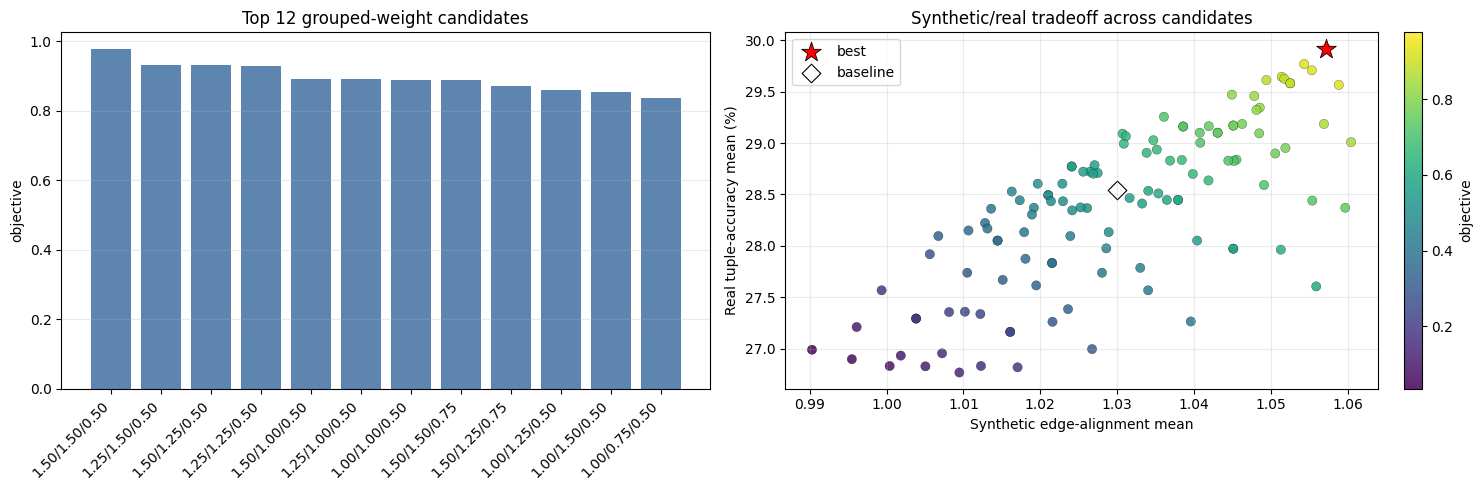

Using grouped fusion weights: (1.5, 1.5, 0.5)
Running with stream_samples=True, max_long_side=768, max_cached_cues=2, gc_every=1, grouped_fusion=True
[synthetic] 0                                | dense_layers=8 tuple_layers=0 fftE=3.75e+09 frft=0.25 spec=0.053 dist=0.320 dwt=0.128 pc=0.984 dcp=0.273 rss=1591.6MB
[synthetic] 1                                | dense_layers=8 tuple_layers=0 fftE=1.98e+09 frft=0.25 spec=0.050 dist=0.329 dwt=0.146 pc=0.994 dcp=0.269 rss=1593.4MB
[synthetic] 2                                | dense_layers=8 tuple_layers=0 fftE=3.24e+09 frft=0.25 spec=0.060 dist=0.279 dwt=0.116 pc=0.993 dcp=0.263 rss=1596.0MB
[synthetic] 3                                | dense_layers=8 tuple_layers=0 fftE=4.92e+09 frft=0.25 spec=0.055 dist=0.261 dwt=0.114 pc=0.990 dcp=0.234 rss=1599.1MB
[real] 000000004                        | dense_layers=0 tuple_layers=2 fftE=9.96e+09 frft=0.25 spec=0.017 dist=0.354 dwt=0.133 pc=0.993 dcp=0.249 rss=1617.1MB
[real] 000000009              

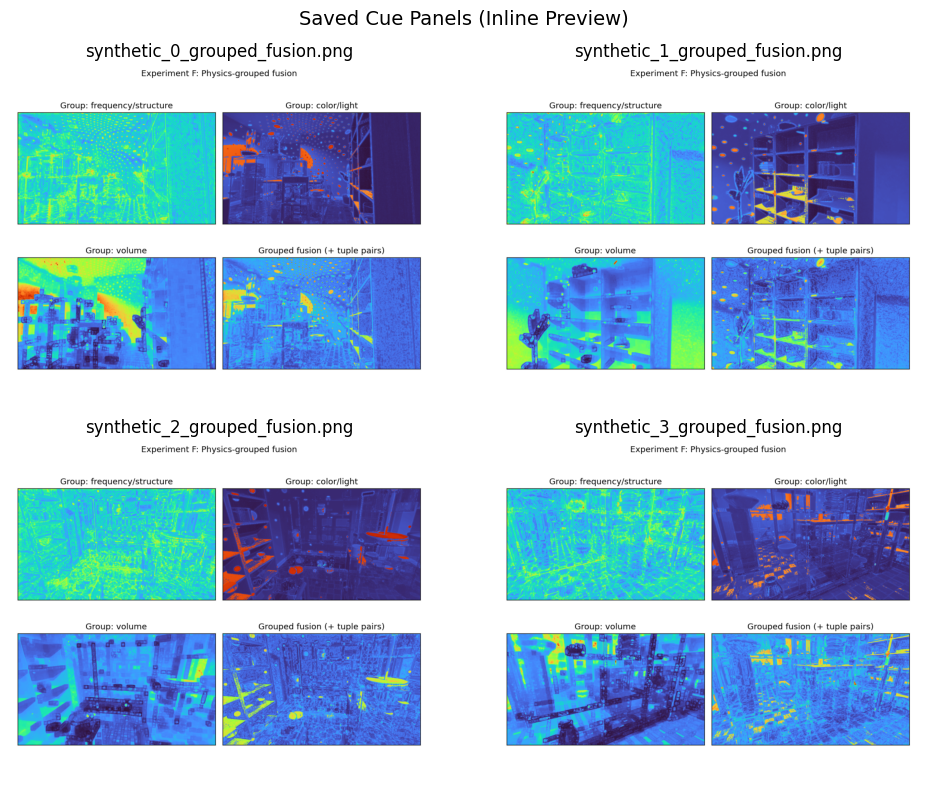

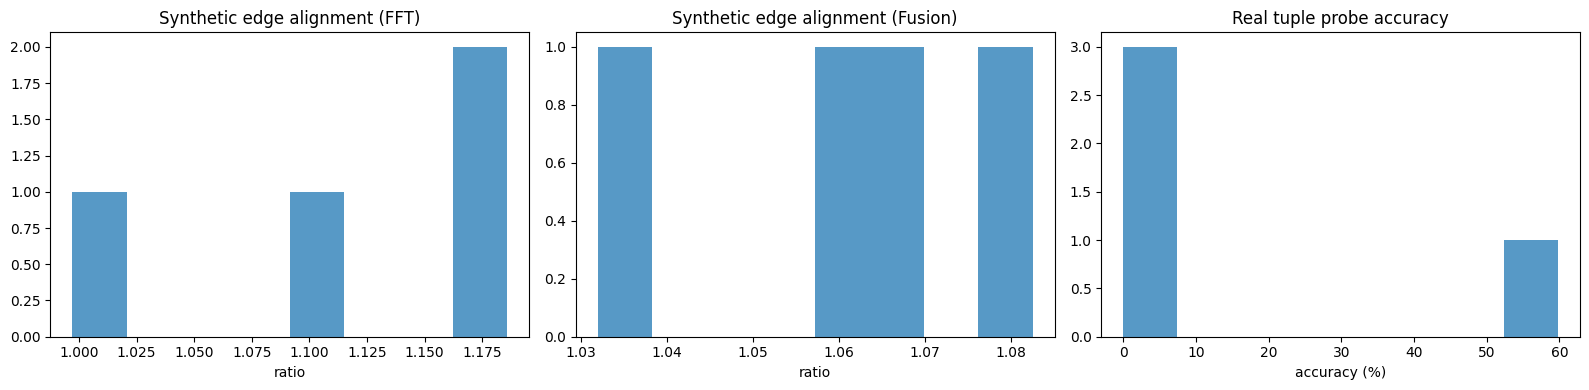

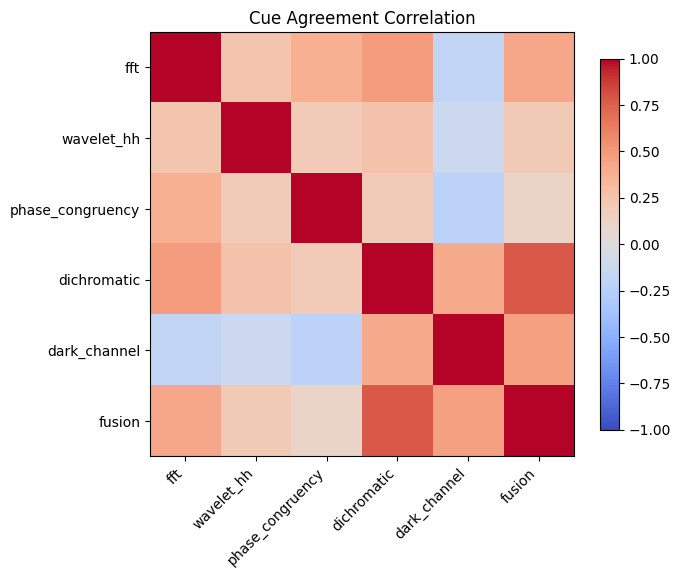

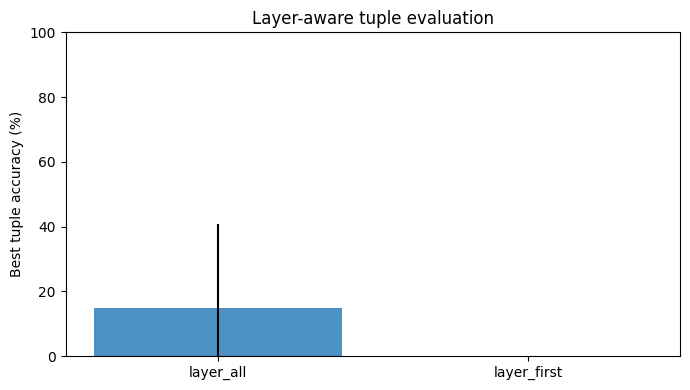

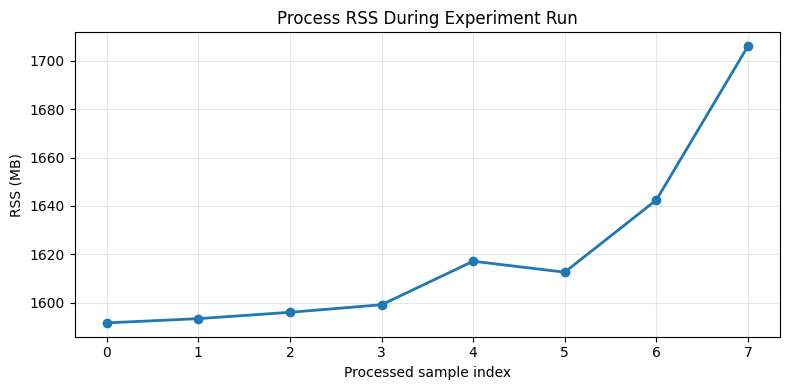

RSS stats -> start=1591.6 MB, peak=1706.1 MB, end=1706.1 MB, delta=114.5 MB


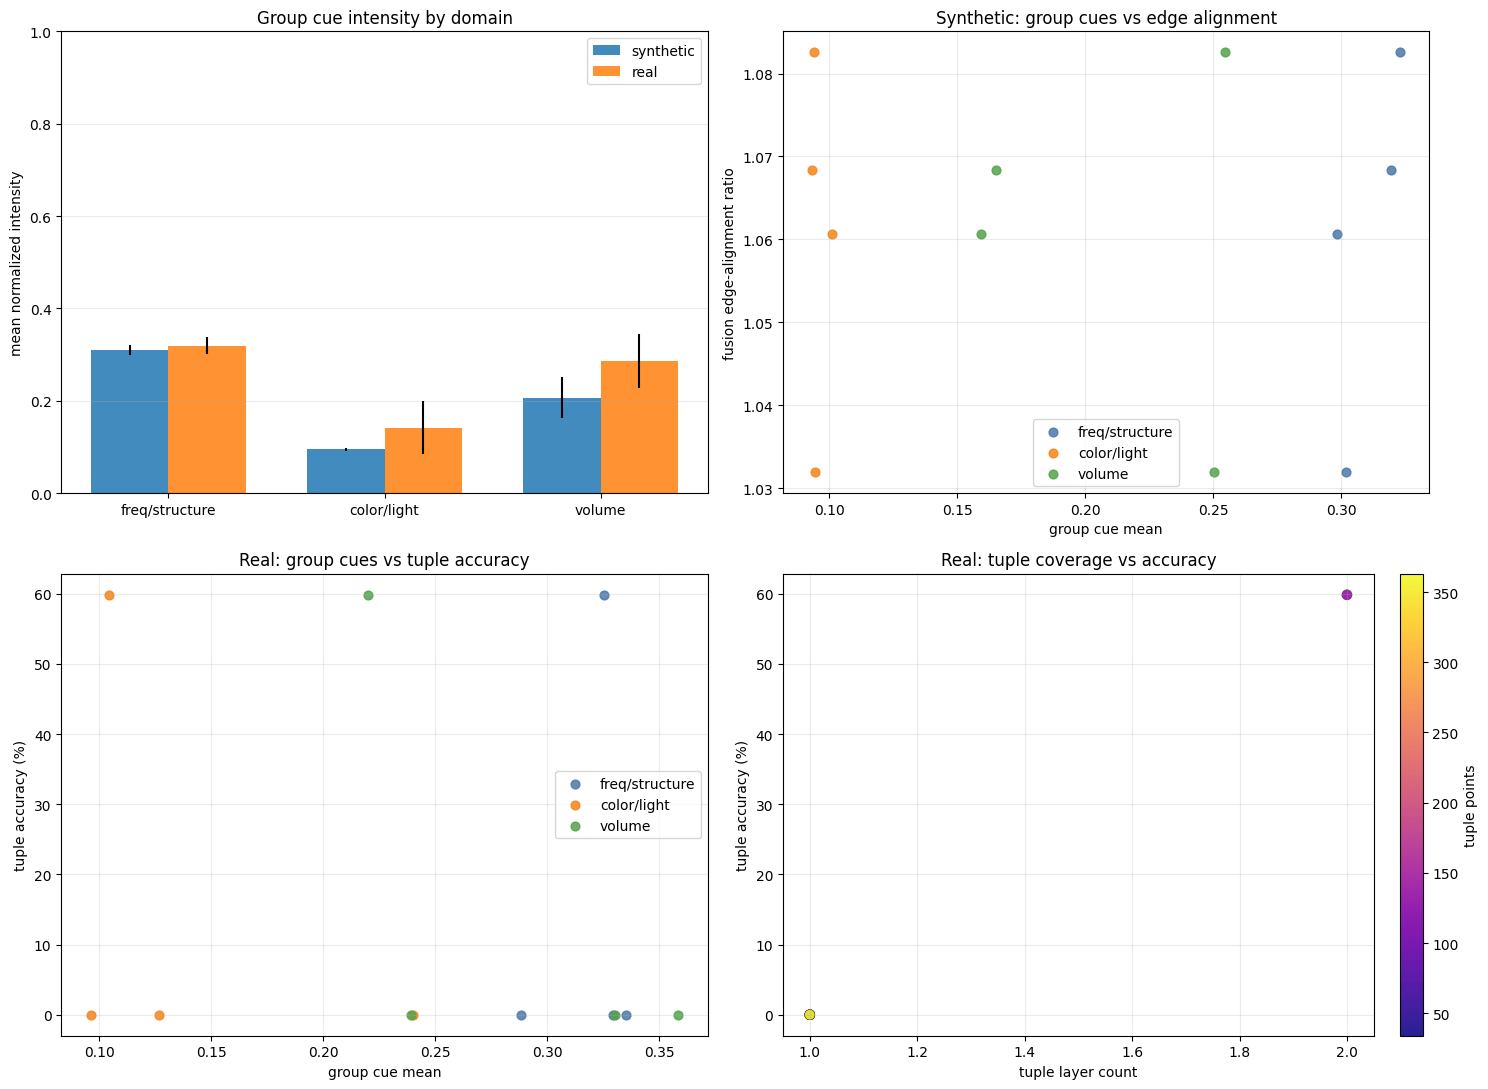

In [62]:
required = [
    "run_experiments",
    "summarize_results",
    "insight_to_model_translation",
    "show_saved_panels",
    "plot_metric_diagnostics",
    "plot_memory_trace",
    "tune_group_weights",
    "plot_weight_tuning_diagnostics",
    "plot_group_component_diagnostics",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Notebook state is incomplete. Run all cells from top before this scenario cell. "
        f"Missing: {missing}"
    )

# OOM-safe defaults for interactive WSL sessions. You can increase these gradually after stable runs.
CFG.max_syn_samples = min(int(CFG.max_syn_samples), 4)
CFG.max_real_samples = min(int(CFG.max_real_samples), 4)
CFG.max_long_side = min(int(CFG.max_long_side), 768)
CFG.max_cached_cues = min(int(CFG.max_cached_cues), 2)
CFG.gc_every = max(1, int(CFG.gc_every))
CFG.stream_samples = True
CFG.log_memory = True
CFG.save_panels = True
CFG.group_weights = _normalize_group_weights(CFG.group_weights)

# Quick calibration search for grouped fusion weights on a tiny subset.
tuning_state = tune_group_weights(
    CFG,
    search_values=(0.50, 0.75, 1.00, 1.25, 1.50),
    max_syn_samples=min(2, int(CFG.max_syn_samples)),
    max_real_samples=min(2, int(CFG.max_real_samples)),
    objective_balance=0.50,
    apply_best=True,
)
plot_weight_tuning_diagnostics(tuning_state, top_k=12)

print("Using grouped fusion weights:", CFG.group_weights)

state = run_experiments(CFG)
summarize_results(state)
insight_to_model_translation(state)
show_saved_panels(state, max_images=4, cols=2)
plot_metric_diagnostics(state)
plot_memory_trace(state)
plot_group_component_diagnostics(state)

## 7. Add Basic Validation Tests

Quick checks to ensure that happy path and edge cases remain stable during iteration.

In [63]:
if "state" not in globals():
    raise RuntimeError("Run the sample scenario cell before running validations.")

# Happy-path checks
assert len(state["records"]) > 0, "No experiment records were produced."

syn_count = sum(1 for r in state["records"] if r.domain == "synthetic")
real_count = sum(1 for r in state["records"] if r.domain == "real")
assert syn_count > 0 or real_count > 0, "Expected at least one loaded sample."

# Finite checks across cached cue bundles (cache is intentionally bounded for memory safety).
for sid, cue in state["cue_store"].items():
    maps_to_check = [
        cue.fft_map,
        cue.fft_spectrum,
        cue.frft_best_map,
        cue.specular_mask,
        cue.distortion_map,
        cue.blur_map,
        cue.laplacian_var_map,
        cue.dof_conflict_map,
        cue.multiscale_detail_map,
        cue.fusion_map,
    ]
    base_shape = maps_to_check[0].shape
    for m in maps_to_check:
        assert m.shape == base_shape, f"Cue map shape mismatch for sample {sid}."
        assert np.isfinite(m).all(), f"Found non-finite values for sample {sid}."

    assert np.isfinite(cue.pyramid_recon_mse), f"Non-finite pyramid reconstruction MSE for sample {sid}."
    assert cue.pyramid_recon_mse >= 0.0, f"Negative pyramid reconstruction MSE for sample {sid}."

    required_components = {
        "fft",
        "frft",
        "specular",
        "distortion",
        "blur",
        "dof_conflict",
        "multiscale",
        "wavelet_hh",
        "dichromatic",
        "phase_congruency",
        "dark_channel",
        "group_frequency_structure",
        "group_color_light",
        "group_volume",
    }
    assert required_components.issubset(set(cue.transparency_components.keys())), (
        f"Missing transparency components for sample {sid}: "
        f"{required_components - set(cue.transparency_components.keys())}"
    )

# Edge case: normalized constant map should stay finite and zero
const_map = np.ones((16, 16), dtype=np.float32)
const_norm = normalize_map(const_map)
assert np.isfinite(const_norm).all()
assert float(const_norm.max()) == 0.0

# Layer-wise tuple accuracy sanity
for r in state["records"]:
    if r.tuple_layer_acc_best is None:
        continue
    for key, val in r.tuple_layer_acc_best.items():
        assert np.isfinite(float(val)), f"Non-finite tuple metric for {r.sample_id} / {key}."
        assert 0.0 <= float(val) <= 100.0, f"Tuple metric out of range for {r.sample_id} / {key}."

# Real split should be tuple-supervised, not dense-depth supervised.
if real_count > 0:
    real_with_tuples = [
        r for r in state["records"]
        if r.domain == "real" and r.tuple_viz_root is not None and r.tuple_layer_ids is not None and len(r.tuple_layer_ids) > 0
    ]
    assert len(real_with_tuples) > 0, "Real samples loaded but tuple GT layers were not extracted."

# Synthetic split should expose variable dense depth layers when present.
if syn_count > 0 and state.get("samples"):
    syn_cached = [s for s in state["samples"].values() if s.domain == "synthetic"]
    if syn_cached:
        max_layers_seen = max(len(s.depth_layers_m) for s in syn_cached)
        assert max_layers_seen >= 2, "Expected at least 2 dense layers in cached synthetic samples."

# Memory trace sanity
mem_trace = state.get("memory_trace", [])
assert len(mem_trace) == len(state["records"]), "Memory trace should contain one entry per processed sample."
rss_vals = [float(m.get("rss_mb", float("nan"))) for m in mem_trace]
assert all(np.isfinite(v) and v > 0.0 for v in rss_vals), "Memory trace contains invalid RSS values."

cfg = state.get("config")
if cfg is not None:
    assert len(state.get("cue_store", {})) <= int(cfg.max_cached_cues), "Cue cache exceeded configured cap."

artifact_dirs = state.get("artifact_dirs", {})
for key in ("images_used", "exp_a", "exp_b", "exp_c", "exp_d", "exp_e", "exp_f"):
    assert key in artifact_dirs, f"Missing artifact dir key: {key}"
    assert Path(artifact_dirs[key]).exists(), f"Artifact dir does not exist: {artifact_dirs[key]}"

fusion_artifacts = list(Path(artifact_dirs["exp_f"]).glob("*.png"))
assert len(fusion_artifacts) > 0, "No grouped fusion artifact images were saved."

# Optional grouped-weight tuning sanity checks.
if "tuning_state" in globals():
    assert isinstance(tuning_state, dict), "tuning_state must be a dict when present."

    best_weights = tuple(float(w) for w in tuning_state.get("best_weights", CFG.group_weights))
    assert len(best_weights) == 3, "Expected exactly 3 group weights (freq/color/volume)."
    assert all(np.isfinite(w) and w > 0.0 for w in best_weights), "Best grouped weights must be positive finite values."

    if not tuning_state.get("skipped", False):
        ranked = tuning_state.get("results", [])
        assert len(ranked) > 0, "Tuning ran but produced no ranked candidates."

        best = tuning_state.get("best")
        assert isinstance(best, dict), "Expected a best candidate dict when tuning is not skipped."
        assert np.isfinite(float(best.get("objective", np.nan))), "Best tuning objective should be finite."

    if tuning_state.get("applied_to_cfg", False):
        applied = _normalize_group_weights(tuple(CFG.group_weights))
        target = _normalize_group_weights(best_weights)
        assert tuple(applied) == tuple(target), "CFG.group_weights does not match tuned best weights."

print("All validation tests passed.")

All validation tests passed.
